# O(3) Bubble Nucleation with Finite Chemical Potential

This notebook studies bubble nucleation in a scalar field theory with finite chemical potential. We consider a potential with two minima: a metastable minimum (false vacuum) and a stable minimum (true vacuum). The finite chemical potential introduces a term $-\omega^2\phi^2$ that modifies the potential landscape.

The grand potential $\Omega(\phi) = V(\phi) - \omega^2\phi^2$ governs the dynamics, where $V(\phi)$ is the underlying potential with two minima. The bubble nucleation solution describes the O(3)-symmetric tunneling from the metastable to the stable vacuum.

The workflow is:
1. Specify model parameters and visualize the grand potential $\Omega(\phi)$.
2. Identify the metastable and stable minima.
3. Solve for the O(3) bubble nucleation profile (bounce solution).
4. Compute the nucleation rate and suppression exponent.

This analysis extends the standard vacuum decay to include finite density effects through the chemical potential term.


## Configuration

All parameters are centralized here. Modify these values to explore different configurations.


In [8]:
# ============================================================================
# Configuration Section
# ============================================================================

import sys
from pathlib import Path

# Setup project path
PROJECT_ROOT = Path.cwd().resolve().parents[1]  # Points to directory containing Bubble_finder
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Model parameters for the potential from [reference]
# V(φ) = -1/2 + (φ - 1)² [2φ - 5 + (2 - φ)² log((2-φ)²(φ₀-1)²/((φ-1)²(φ₀-2)²))]
# This potential has a false minimum at φ = 1 and true minimum at φ = 2
# It admits a d=4 bounce solution with known analytical action for Q=0
PHI0 = 1.999       # Field value at center of bounce (for numerics)
V1 = 1.0          # False vacuum (metastable minimum)
V2 = 2.0          # True vacuum (stable minimum)

# Chemical potential (finite density parameter)
OMEGA = 0.4       # Chemical potential ω


print(f"Configuration loaded:")
print(f"  Project root: {PROJECT_ROOT}")
print(f"  Model: Potential with false vacuum at φ={V1}, true vacuum at φ={V2}")
print(f"  φ₀ = {PHI0} (field value at center for numerics)")
print(f"  Chemical potential: ω = {OMEGA}")
print(f"  Tunneling: from φ={V1} (metastable) to φ={V2} (stable)")

Configuration loaded:
  Project root: /home/giulio/Madrid - PostDoc/Projects/Finite Density Vacuum decay/BubbleX
  Model: Potential with false vacuum at φ=1.0, true vacuum at φ=2.0
  φ₀ = 1.999 (field value at center for numerics)
  Chemical potential: ω = 0.4
  Tunneling: from φ=1.0 (metastable) to φ=2.0 (stable)


In [9]:
# ============================================================================
# Imports
# ============================================================================

import matplotlib.pyplot as plt
import numpy as np
from scipy.special import spence  # For dilogarithm Li₂ (Li₂(z) = spence(1-z))

# Configure matplotlib for publication-quality figures
import matplotlib as mpl
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath}\usepackage{siunitx}",
    "font.size": 15,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.titlesize": 20,
})
plt.rcParams["figure.figsize"] = (7, 4.8)

print("Imports completed successfully.")


Imports completed successfully.


## Model Parameters and Grand Potential

We consider a scalar field theory with a specific potential that admits an analytical bounce solution for $d=4$ and $Q=0$. The underlying potential is:

$$V(\phi) = -\frac{1}{2} + (\phi - 1)^2 \left[ 2\phi - 5 + (2 - \phi)^2 \log \frac{(2 - \phi)^2 (\phi_0 - 1)^2}{(\phi - 1)^2 (\phi_0 - 2)^2} \right]$$

where $\phi_0$ is the field value at the center of the bounce (we take $\phi_0 = 1.999$ for numerics). This potential is valid for $\phi \in [1, 2]$ and has:
- **False vacuum** (metastable minimum) at $\phi = 1$
- **True vacuum** (stable minimum) at $\phi = 2$
- **Tunneling** occurs from $\phi = 1$ to $\phi = 2$

**Analytical Reference:**

For $Q = 0$ and $d=4$, the Euclidean action is known analytically:

$$S_0 = -\frac{\pi^2}{3} \left[ \phi_0 - 1 + \text{Li}_2 \left( \frac{\phi_0 - 1}{\phi_0 - 2} \right) \right]$$

where $\text{Li}_2$ is the dilogarithm function. This provides a benchmark for our numerical calculations.

**Finite Chemical Potential:**

The finite chemical potential $\omega$ modifies the potential through the term $-\omega^2\phi^2$, giving the grand potential:

$$\Omega(\phi) = V(\phi) - \omega^2\phi^2$$

The grand potential $\Omega(\phi)$ has minima that are shifted from $\phi = 1$ and $\phi = 2$ due to the $\omega^2$ term. The bubble nucleation solution describes the O(3)-symmetric tunneling from the metastable minimum (shifted from $\phi = 1$) to the stable minimum (shifted from $\phi = 2$) in this grand potential landscape.

**Why This Potential?**

This potential is particularly useful because:
1. It has a known analytical bounce action for $d=4$ and $Q=0$, allowing us to validate our numerical methods
2. It provides a non-trivial test case for studying finite density effects
3. The logarithmic structure makes it more challenging than polynomial potentials, testing the robustness of our numerical solver


Analytical Euclidean action (d=4, Q=0): S₀ = 80.590466
Minima of grand potential Ω(φ):
  False vacuum (metastable): φ = 1.008417, Ω = -0.661289
  True vacuum (stable):     φ = 2.101804, Ω = -2.173610
  Energy difference:        ΔΩ = 1.512321

Note: The underlying potential V(φ) has minima at v1=1.0 and v2=2.0.
      The grand potential Ω = V - ω² φ² shifts these minima slightly.
      False vacuum is near v1=1.0 (shift: +0.0084)
      True vacuum is near v2=2.0 (shift: +0.1018)


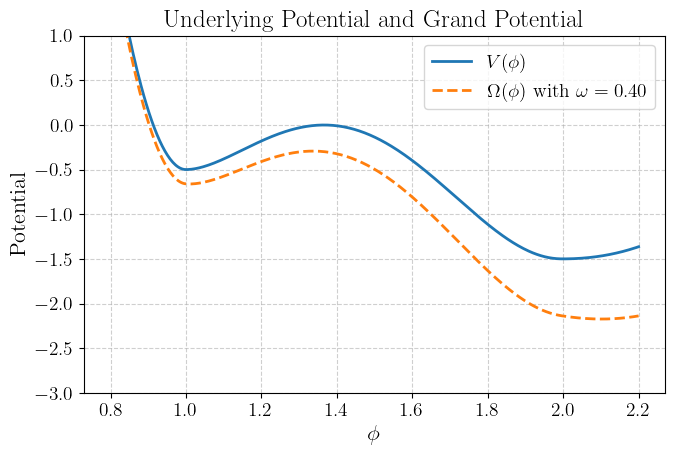

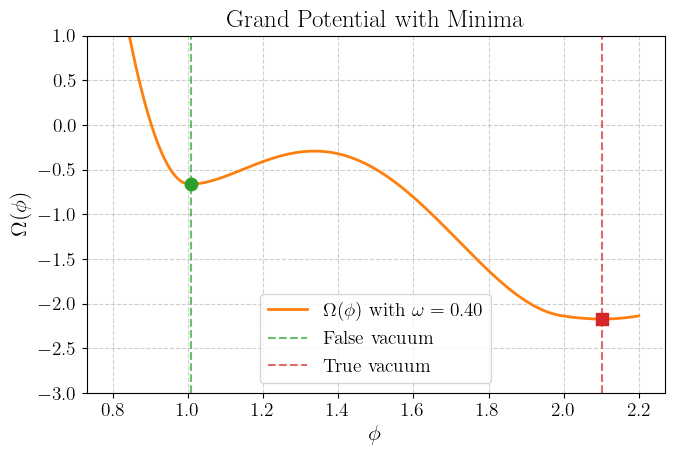

In [10]:
# Define the underlying potential V(φ)
def V_phi(phi, phi0, v1, v2):
    """
    Underlying potential: V(φ) = -1/2 + (φ - 1)² [2φ - 5 + (2 - φ)² log((2-φ)²(φ₀-1)²/((φ-1)²(φ₀-2)²))]
    This potential has false minimum at φ = v1 = 1 and true minimum at φ = v2 = 2
    Valid for φ in [v1, v2] = [1, 2]
    """
    # Check if input is scalar or array
    is_scalar = np.isscalar(phi) or (isinstance(phi, np.ndarray) and phi.ndim == 0)
    
    # Convert to array for calculations
    phi_arr = np.asarray(phi)
    phi_flat = phi_arr.flatten() if phi_arr.ndim > 0 else np.array([phi_arr])
    
    # Evaluate the potential as-is, without clipping or restrictions
    # This allows the potential to be evaluated anywhere, which is important
    # for finding minima that may be shifted by the omega term
    
    # Compute the logarithmic term
    # log((2-φ)²(φ₀-1)²/((φ-1)²(φ₀-2)²))
    # Use a small epsilon only to avoid numerical issues at exact boundaries
    phi_for_log = np.clip(phi_flat, v1 + 1e-12, v2 - 1e-12)
    log_arg = ((2 - phi_for_log)**2 * (phi0 - v1)**2) / ((phi_for_log - v1)**2 * (phi0 - v2)**2)
    log_term = (2 - phi_for_log)**2 * np.log(log_arg)
    
    # Full potential - evaluate everywhere without restrictions
    V_flat = -0.5 + (phi_flat - v1)**2 * (2*phi_flat - 5 + log_term)
    
    # Reshape to match input shape
    if is_scalar:
        return float(V_flat[0])
    else:
        V = V_flat.reshape(phi_arr.shape)
        return V

# Define the grand potential Ω(φ) = V(φ) - ω² φ²
def Omega_phi(phi, phi0, v1, v2, omega):
    """
    Grand potential: Ω(φ) = V(φ) - ω² φ²
    """
    V = V_phi(phi, phi0, v1, v2)
    return V - omega**2 * phi**2

# Analytical Euclidean action for d=4, Q=0
def S0_analytical(phi0):
    """
    Analytical Euclidean action for d=4 bounce with Q=0:
    S₀ = -π²/3 [φ₀ - 1 + Li₂((φ₀-1)/(φ₀-2))]
    Uses spence from scipy.special: Li₂(z) = spence(1-z)
    """
    term = (phi0 - 1) / (phi0 - 2)
    # Li₂(z) = spence(1-z) for dilogarithm
    Li2_val = spence(1 - term)
    S0 = -np.pi**2 / 3.0 * (phi0 - 1 + Li2_val)
    return S0

# Create potential parameters from configuration
phi0 = PHI0
v1 = V1
v2 = V2
omega = OMEGA

# Calculate analytical action for reference
S0_anal = S0_analytical(phi0)
print(f"Analytical Euclidean action (d=4, Q=0): S₀ = {S0_anal:.6f}")

# Find the minima first (needed for plotting)
# Search for minima near v1 and v2 using a fine grid
# The grand potential Ω = V - ω² φ² shifts the minima slightly from v1 and v2
# Use a fine grid to accurately locate the minima
phi_grid1 = np.linspace(max(0.5, v1 - 0.2), min(v2 - 0.1, v1 + 0.2), 500)
phi_grid2 = np.linspace(max(v1 + 0.1, v2 - 0.2), min(2.5, v2 + 0.4), 500)
Omega_grid1 = np.array([Omega_phi(phi, phi0, v1, v2, omega) for phi in phi_grid1])
Omega_grid2 = np.array([Omega_phi(phi, phi0, v1, v2, omega) for phi in phi_grid2])

# Find the minima from the grid (fine enough for good accuracy)
idx_min1 = np.argmin(Omega_grid1)
idx_min2 = np.argmin(Omega_grid2)
phi_near_v1 = phi_grid1[idx_min1]
phi_near_v2 = phi_grid2[idx_min2]
Omega_near_v1 = Omega_phi(phi_near_v1, phi0, v1, v2, omega)
Omega_near_v2 = Omega_phi(phi_near_v2, phi0, v1, v2, omega)

# Determine which is metastable and which is stable
# The one with higher energy is metastable (false vacuum)
# The one with lower energy is stable (true vacuum)
if Omega_near_v1 > Omega_near_v2:
    phi_false = phi_near_v1  # Near v1, metastable
    phi_true = phi_near_v2   # Near v2, stable
    Omega_false = Omega_near_v1
    Omega_true = Omega_near_v2
else:
    phi_false = phi_near_v2  # Near v2, metastable
    phi_true = phi_near_v1   # Near v1, stable
    Omega_false = Omega_near_v2
    Omega_true = Omega_near_v1

print(f"Minima of grand potential Ω(φ):")
print(f"  False vacuum (metastable): φ = {phi_false:.6f}, Ω = {Omega_false:.6f}")
print(f"  True vacuum (stable):     φ = {phi_true:.6f}, Ω = {Omega_true:.6f}")
print(f"  Energy difference:        ΔΩ = {Omega_false - Omega_true:.6f}")
print(f"\nNote: The underlying potential V(φ) has minima at v1={v1} and v2={v2}.")
print(f"      The grand potential Ω = V - ω² φ² shifts these minima slightly.")
if abs(phi_false - v1) < abs(phi_false - v2):
    print(f"      False vacuum is near v1={v1} (shift: {phi_false - v1:+.4f})")
else:
    print(f"      False vacuum is near v2={v2} (shift: {phi_false - v2:+.4f})")
if abs(phi_true - v1) < abs(phi_true - v2):
    print(f"      True vacuum is near v1={v1} (shift: {phi_true - v1:+.4f})")
else:
    print(f"      True vacuum is near v2={v2} (shift: {phi_true - v2:+.4f})")

# Plot both V(φ) and Ω(φ) for comparison
phi_range = np.linspace(v1 -0.2, v2 +0.2, 400)
V_vals = np.array([V_phi(phi, phi0, v1, v2) for phi in phi_range])
Omega_vals = np.array([Omega_phi(phi, phi0, v1, v2, omega) for phi in phi_range])

fig, ax = plt.subplots(figsize=(7, 4.8))
ax.plot(phi_range, V_vals, label=r"$V(\phi)$", lw=2, color='C0')
ax.plot(phi_range, Omega_vals,
        label=rf"$\Omega(\phi)$ with $\omega={omega:.2f}$", lw=2, color='C1', linestyle='--')
ax.set_xlabel(r"$\phi$")
ax.set_ylabel(r"Potential")
ax.set_title("Underlying Potential and Grand Potential")
ax.set_ylim(-3, 1)
ax.legend()
ax.grid(True, ls="--", alpha=0.6)
plt.tight_layout()
plt.show()

# Detailed plot of grand potential with minima marked
fig, ax = plt.subplots(figsize=(7, 4.8))
ax.plot(phi_range, Omega_vals, label=rf"$\Omega(\phi)$ with $\omega={omega:.2f}$",
        lw=2, color='C1')

# Mark the minima
ax.axvline(phi_false, color='C2', ls='--', lw=1.5, label='False vacuum', alpha=0.7)
ax.axvline(phi_true, color='C3', ls='--', lw=1.5, label='True vacuum', alpha=0.7)
ax.scatter([phi_false], [Omega_false], color='C2', zorder=5, s=80, marker='o')
ax.scatter([phi_true], [Omega_true], color='C3', zorder=5, s=80, marker='s')

ax.set_xlabel(r"$\phi$")
ax.set_ylabel(r"$\Omega(\phi)$")
ax.set_title("Grand Potential with Minima")
ax.set_ylim(-3, 1)
ax.legend(loc='best')
ax.grid(True, ls="--", alpha=0.6)
plt.tight_layout()
plt.show()


## O(3) Bounce Solution

The O(3)-symmetric bounce solution describes the tunneling from the false vacuum (metastable) to the true vacuum (stable) in the grand potential $\Omega(\phi)$. The bounce solution $\phi(r)$ satisfies the Euclidean equation of motion:

$$\frac{d^2\phi}{dr^2} + \frac{2}{r}\frac{d\phi}{dr} = \frac{d\Omega}{d\phi}$$

with boundary conditions:
- $\phi(0) = \phi_0$ (field value at the center, determined by the shooting method)
- $\phi'(0) = 0$ (regularity at the origin)
- $\phi(r \to \infty) = \phi_{\text{false}}$ (asymptotic false vacuum)

**Solution Method:**

We use a robust shooting method with bisection on $\phi(0)$:
- **Overshoot**: If $\phi(0)$ is too large, the solution crosses $\phi_{\text{false}}$ going downward
- **Undershoot**: If $\phi(0)$ is too small, $\phi'(r)$ hits zero before reaching $\phi_{\text{false}}$
- The correct $\phi(0)$ is found when the solution converges to $\phi_{\text{false}}$ with $\phi'(r \to \infty) \to 0$

The integration stops when $\phi'(r)$ changes sign, indicating that the solution has reached its turning point and is converging to the false vacuum.

**Note:** The underlying potential $V(\phi)$ has minima at $\phi = 1$ (false) and $\phi = 2$ (true), but the grand potential $\Omega(\phi) = V(\phi) - \omega^2\phi^2$ shifts these minima slightly. The bounce solution tunnels between the shifted minima of $\Omega$.

Solving O(3) bounce solution...
Parameters: φ₀=1.999, v1=1.0, v2=2.0, ω=0.5
Analytical action (d=4, Q=0): S₀ = 80.590466
Vacua of Ω: phi_false=1.0146429059, phi_true=2.1554548034
  Iteration 0: Undershoot, φ(0)=1.585049, φ(∞)=1.258977, r_stop=1.1792
  Iteration 10: Undershoot, φ(0)=1.984444, φ(∞)=1.018909, r_stop=2.1136
  Iteration 20: Undershoot, φ(0)=1.984624, φ(∞)=1.014706, r_stop=2.8421
  Converged after 27 iterations: φ(0)=1.984625, φ(∞)=1.014643, φ'(∞)=-7.503e-05

Bounce solution found:
  φ(0) = 1.984625
  φ(∞) ≈ 1.014643 (target false = 1.014643)
  r_max = 3.09
  Number of points: 1000
  phi range: [1.014643, 1.984625]


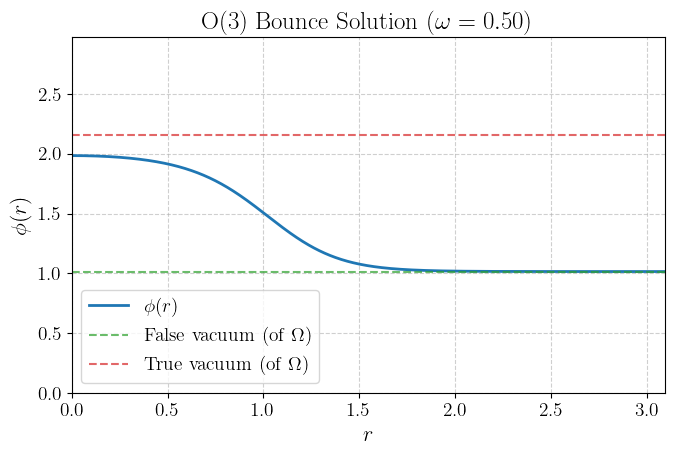

In [12]:
# ============================================================================
# Bounce Solution Solver (Robust Method with Analytical Vacua)
# ============================================================================

from scipy.integrate import solve_ivp

# ============================================================================
# Parameters (modify these to change the calculation)
# ============================================================================
# Use values from configuration by default, or override here:
PHI0_BOUNCE = PHI0    # Field value at center
V1_BOUNCE = V1        # False vacuum (metastable minimum)
V2_BOUNCE = V2        # True vacuum (stable minimum)
OMEGA_BOUNCE = OMEGA  # Chemical potential ω

# Solver parameters:
D = 3                   # Spatial dimension (3 for O(3) symmetry)
R0 = 1e-8              # Initial radius
RMAX = 10.0            # Maximum integration radius
MAX_ITER = 100          # Maximum bisection iterations
VERBOSE = True          # Print progress

# Override with custom values if needed:
OMEGA_BOUNCE = 0.5
# ============================================================================

from scipy.optimize import minimize_scalar

def dV_dphi(phi, phi0, v1, v2):
    """
    First derivative of V(φ) with respect to φ.
    V(φ) = -1/2 + (φ - 1)² [2φ - 5 + (2 - φ)² log((2-φ)²(φ₀-1)²/((φ-1)²(φ₀-2)²))]
    Must be consistent with V_phi: use clipping only for log calculation, not for other terms.
    """
    # Check if input is scalar or array (same as V_phi)
    is_scalar = np.isscalar(phi) or (isinstance(phi, np.ndarray) and phi.ndim == 0)
    phi_arr = np.asarray(phi)
    phi_flat = phi_arr.flatten() if phi_arr.ndim > 0 else np.array([phi_arr])
    
    # Use clipping only for log calculation (consistent with V_phi)
    phi_for_log = np.clip(phi_flat, v1 + 1e-12, v2 - 1e-12)
    
    # Terms using original phi (not clipped) - consistent with V_phi
    term1 = (phi_flat - v1)**2  # (φ - 1)²
    term2 = 2*phi_flat - 5
    
    # Log term uses clipped phi to avoid numerical issues
    log_arg = ((2 - phi_for_log)**2 * (phi0 - v1)**2) / ((phi_for_log - v1)**2 * (phi0 - v2)**2)
    term3 = (2 - phi_for_log)**2 * np.log(log_arg)
    
    # Derivatives
    d_term1 = 2 * (phi_flat - v1)  # d/dφ of (φ-1)² = 2(φ-1)
    d_term2 = 2  # d/dφ of [2φ - 5] = 2
    
    # d/dφ of (2-φ)² log(...)
    # log(...) = 2log(2-φ) + 2log(φ₀-1) - 2log(φ-1) - 2log(φ₀-2)
    # d/dφ log(...) = -2/(2-φ) - 2/(φ-1)
    d_log = -2/(2 - phi_for_log) - 2/(phi_for_log - v1)
    d_term3 = -2*(2 - phi_for_log)*np.log(log_arg) + (2 - phi_for_log)**2 * d_log
    
    # Final derivative: use original phi for main terms, clipped phi only for log-related terms
    dV_flat = d_term1 * (term2 + term3) + term1 * (d_term2 + d_term3)
    
    # Reshape to match input shape (consistent with V_phi)
    if is_scalar:
        dV = float(dV_flat[0])
    else:
        dV = dV_flat.reshape(phi_arr.shape)
    
    # Return as scalar or array
    if isinstance(phi, np.ndarray):
        return dV
    else:
        return float(dV)

def d2V_dphi2(phi, phi0, v1, v2):
    """
    Second derivative of V(φ) with respect to φ.
    Computed numerically for robustness.
    """
    h = 1e-6
    dV_plus = dV_dphi(phi + h, phi0, v1, v2)
    dV_minus = dV_dphi(phi - h, phi0, v1, v2)
    return (dV_plus - dV_minus) / (2 * h)

def dOmega_dphi(phi, phi0, v1, v2, omega):
    """First derivative of grand potential: dΩ/dφ = dV/dφ - 2ω² φ"""
    dV = dV_dphi(phi, phi0, v1, v2)
    return dV - 2.0 * omega**2 * phi

def d2Omega_dphi2(phi, phi0, v1, v2, omega):
    """Second derivative of grand potential: d²Ω/dφ² = d²V/dφ² - 2ω²"""
    d2V = d2V_dphi2(phi, phi0, v1, v2)
    return d2V - 2.0 * omega**2

def vacua_of_Omega(phi0, v1, v2, omega):
    """
    Find false and true vacua by solving Ω'(φ) = 0 numerically.
    Returns phi_false (metastable, higher energy) and phi_true (stable, lower energy).
    Uses the same simple approach as cell 5: two separate grids, find minimum in each, then refine.
    Uses Omega_phi from cell 5 to ensure consistency.
    """
    from scipy.optimize import minimize
    
    # Step 1: Find approximate minima using two separate grids (exactly as in cell 5)
    # Search for minima near v1 and v2 using separate fine grids
    phi_grid1 = np.linspace(max(0.5, v1 - 0.2), min(v2 - 0.1, v1 + 0.2), 500)
    phi_grid2 = np.linspace(max(v1 + 0.1, v2 - 0.2), min(2.5, v2 + 0.2), 500)
    Omega_grid1 = np.array([Omega_phi(p, phi0, v1, v2, omega) for p in phi_grid1])
    Omega_grid2 = np.array([Omega_phi(p, phi0, v1, v2, omega) for p in phi_grid2])
    
    # Find the minima from each grid
    idx_min1 = np.argmin(Omega_grid1)
    idx_min2 = np.argmin(Omega_grid2)
    guess1 = phi_grid1[idx_min1]
    guess2 = phi_grid2[idx_min2]
    
    # Step 2: Refine the minima using minimize with initial guesses
    bounds = [(max(0.5, v1 - 0.2), min(2.5, v2 + 0.2))]
    
    try:
        res1 = minimize(
            lambda p: Omega_phi(p[0], phi0, v1, v2, omega),
            x0=[guess1],
            method='L-BFGS-B',
            bounds=bounds,
            options={'ftol': 1e-10}
        )
        phi_min1 = res1.x[0] if res1.success else guess1
    except:
        phi_min1 = guess1
    
    try:
        res2 = minimize(
            lambda p: Omega_phi(p[0], phi0, v1, v2, omega),
            x0=[guess2],
            method='L-BFGS-B',
            bounds=bounds,
            options={'ftol': 1e-10}
        )
        phi_min2 = res2.x[0] if res2.success else guess2
    except:
        phi_min2 = guess2
    
    # Determine which is false (higher energy) and which is true (lower energy)
    Om_min1 = Omega_phi(phi_min1, phi0, v1, v2, omega)
    Om_min2 = Omega_phi(phi_min2, phi0, v1, v2, omega)
    
    if Om_min1 > Om_min2:
        phi_false, phi_true = phi_min1, phi_min2
    else:
        phi_false, phi_true = phi_min2, phi_min1
    
    return phi_false, phi_true


def solve_bounce(phi0, v1, v2, omega, d=3, r0=1e-6, rmax=500.0, max_iter=100, verbose=False, extend_to=None, n_grid_points=1000):
    """
    Robust bounce solution finder using overshoot/undershoot with events.
    
    Uses bisection on φ(0) with events:
    - event_phi_false: φ crosses phi_false (overshoot)
    - event_dphi_zero: φ' crosses zero (undershoot)
    
    Parameters
    ----------
    phi0, v1, v2, omega : float
        Potential parameters: phi0 (field value at center), v1 (false vacuum), v2 (true vacuum), omega (chemical potential)
    d : int
        Spatial dimension (default 3 for O(3) symmetry)
    r0, rmax : float
        Integration range
    max_iter : int
        Maximum bisection iterations
    verbose : bool
        Print progress
    extend_to : float, optional
        If provided, extend solution to this r value after reaching phi_false
        (solution stays constant at phi_false beyond the event point)
    n_grid_points : int
        Number of points in the solution grid (default 1000, increase for higher precision)
        
    Returns
    -------
    r, phi, phi0_init, phi_false, phi_true : arrays/float
        Solution arrays and initial/final values
    """
    # Get vacua numerically
    phi_false, phi_true = vacua_of_Omega(phi0, v1, v2, omega)
    if verbose:
        print(f"Vacua of Ω: phi_false={phi_false:.10f}, phi_true={phi_true:.10f}")

    # Bisection bounds: φ(0) should be between phi_true and phi_false
    phi_L = min(phi_true, phi_false)
    phi_R = max(phi_true, phi_false)
    
    # Events
    def event_phi_false(r, y):
        """Event: φ crosses phi_false going downward (overshoot)"""
        return y[0] - phi_false
    event_phi_false.terminal = True
    event_phi_false.direction = -1  # Only trigger when crossing downward
    
    def event_dphi_zero(r, y):
        """Event: φ' crosses zero (undershoot), but avoid trigger at r=r0"""
        return y[1] if r > 10*r0 else 1.0
    event_dphi_zero.terminal = True
    event_dphi_zero.direction = 1
    
    r_stop = rmax
    sol_final = None
    sol_best = None
    phi0_best = None
    
    for iteration in range(max_iter):
        phi0_init = 0.5 * (phi_L + phi_R)
        
        # ODE: φ'' + (d-1)/r φ' = dΩ/dφ
        sol = solve_ivp(
            fun=lambda r, y: [y[1], -(d-1)/r * y[1] + dOmega_dphi(y[0], phi0, v1, v2, omega)],
            t_span=(r0, rmax),
            y0=[phi0_init, 0.0],
            method='BDF',
            events=[event_phi_false, event_dphi_zero],
            dense_output=True,
            max_step=np.inf,
            atol=1e-8,
            rtol=1e-8
        )
        
        if not sol.success:
            if verbose:
                print(f"  Iteration {iteration}: Integration failed for φ(0)={phi0_init:.6f}")
            # Adjust bounds slightly
            phi_L = phi_L + 0.01 * (phi0_init - phi_L)
            phi_R = phi_R - 0.01 * (phi_R - phi0_init)
            continue
        
        # Check which event fired first
        t_phi_event = sol.t_events[0][0] if sol.t_events[0].size > 0 else np.inf
        t_dphi_event = sol.t_events[1][0] if sol.t_events[1].size > 0 else np.inf
        
        # Get final values for convergence check
        phi_end = sol.y[0, -1]
        dphi_end = sol.y[1, -1]
        
        if t_dphi_event < t_phi_event:
            # Undershoot: φ' hit zero first → φ(0) too small, need to increase
            phi_L = phi0_init
            r_stop = t_dphi_event
            if verbose and iteration % 10 == 0:
                print(f"  Iteration {iteration}: Undershoot, φ(0)={phi0_init:.6f}, φ(∞)={phi_end:.6f}, r_stop={r_stop:.4f}")
        elif t_phi_event < np.inf:
            # Overshoot: φ crossed phi_false going down → φ(0) too large, need to decrease
            phi_R = phi0_init
            r_stop = t_phi_event
            if verbose and iteration % 10 == 0:
                print(f"  Iteration {iteration}: Overshoot, φ(0)={phi0_init:.6f}, φ(∞)={phi_end:.6f}, r_stop={r_stop:.4f}")
        else:
            # No event fired: check if we're close to phi_false
            if phi_end > phi_false:
                # Still above phi_false → undershoot, need to increase φ(0)
                phi_L = phi0_init
                if verbose and iteration % 10 == 0:
                    print(f"  Iteration {iteration}: No event, above false, φ(0)={phi0_init:.6f}, φ(∞)={phi_end:.6f}")
            else:
                # Below phi_false → overshoot, need to decrease φ(0)
                phi_R = phi0_init
                if verbose and iteration % 10 == 0:
                    print(f"  Iteration {iteration}: No event, below false, φ(0)={phi0_init:.6f}, φ(∞)={phi_end:.6f}")
        
        sol_final = sol.sol
        sol_best = sol
        phi0_best = phi0_init
        
        # Check convergence: bounds are close
        if abs(phi_R - phi_L) < 1e-8:
            if verbose:
                print(f"  Converged after {iteration+1} iterations: φ(0)={phi0_init:.6f}, φ(∞)={phi_end:.6f}, φ'(∞)={dphi_end:.3e}")
            break
    
    if sol_best is None or not sol_best.success:
        if verbose:
            print("  Failed to find solution")
        return None, None, None, None, None
    
    # Extract solution using dense_output on a grid
    # The solution stops when φ' changes sign (event_dphi_zero) or when it reaches phi_false (event_phi_false)
    r_end = sol_best.t[-1]
    
    # Create a grid and evaluate using dense_output
    r_grid = np.linspace(r0, r_end, n_grid_points)
    phi_grid = sol_best.sol(r_grid)[0]
    
    # Optionally extend solution beyond r_end if extend_to is specified
    if extend_to is not None and extend_to > r_end:
        # Continue ODE integration from r_end to extend_to using final conditions
        phi_end_val = sol_best.y[0, -1]
        dphi_end_val = sol_best.y[1, -1]
        
        # Continue integration without events (just integrate to extend_to)
        sol_extend = solve_ivp(
            fun=lambda r, y: [y[1], -(d-1)/r * y[1] + dOmega_dphi(y[0], phi0, v1, v2, omega)],
            t_span=(r_end, extend_to),
            y0=[phi_end_val, dphi_end_val],
            method='BDF',
            dense_output=True,
            max_step=np.inf,
            atol=1e-8,
            rtol=1e-8
        )
        
        if sol_extend.success:
            # Number of points for extension (proportional to length)
            n_extend = int(n_grid_points * (extend_to - r_end) / (r_end - r0))
            n_extend = max(200, min(n_extend, 1000))  # Between 200 and 1000 points
            r_extend = np.linspace(r_end, extend_to, n_extend)
            phi_extend = sol_extend.sol(r_extend)[0]
            
            # Combine original and extended solution (skip duplicate point at r_end)
            r_grid = np.concatenate([r_grid, r_extend[1:]])
            phi_grid = np.concatenate([phi_grid, phi_extend[1:]])
        else:
            # Fallback: if extension fails, use constant value
            if verbose:
                print(f"  Warning: Extension integration failed, using constant phi_false")
            n_extend = int(n_grid_points * (extend_to - r_end) / (r_end - r0))
            n_extend = max(200, min(n_extend, 1000))
            r_extend = np.linspace(r_end, extend_to, n_extend)
            phi_extend = np.full_like(r_extend, phi_false)
            r_grid = np.concatenate([r_grid, r_extend[1:]])
            phi_grid = np.concatenate([phi_grid, phi_extend[1:]])
    
    phi0_final = float(phi0_best) if phi0_best is not None else float(phi0)
    
    return r_grid, phi_grid, phi0_final, phi_false, phi_true

# Solve bounce with chosen parameters
print("Solving O(3) bounce solution...")
print(f"Parameters: φ₀={PHI0_BOUNCE}, v1={V1_BOUNCE}, v2={V2_BOUNCE}, ω={OMEGA_BOUNCE}")
print(f"Analytical action (d=4, Q=0): S₀ = {S0_analytical(PHI0_BOUNCE):.6f}")
r_bounce, phi_bounce, phi0_bounce, phi_false_bounce, phi_true_bounce = solve_bounce(
    PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, OMEGA_BOUNCE, 
    d=D, r0=R0, rmax=RMAX, max_iter=MAX_ITER, verbose=VERBOSE
)

# Bounce at ω=0 (reference for comparison)
r_bounce_0, phi_bounce_0, phi0_bounce_0, phi_false_bounce_0, phi_true_bounce_0 = solve_bounce(
    PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, 0.0,
    d=D, r0=R0, rmax=RMAX, max_iter=MAX_ITER, verbose=False
)

if r_bounce is not None:
    print(f"\nBounce solution found:")
    print(f"  φ(0) = {phi0_bounce:.6f}")
    print(f"  φ(∞) ≈ {phi_bounce[-1]:.6f} (target false = {phi_false_bounce:.6f})")
    print(f"  r_max = {r_bounce[-1]:.2f}")
    print(f"  Number of points: {len(r_bounce)}")
    print(f"  phi range: [{phi_bounce.min():.6f}, {phi_bounce.max():.6f}]")
    
    # Update phi_false and phi_true with analytical values
    phi_false = phi_false_bounce
    phi_true = phi_true_bounce
    
    # Plot bounce solution
    fig, ax = plt.subplots(figsize=(7, 4.8))
    ax.plot(r_bounce, phi_bounce, lw=2, color='C0', label=r"$\phi(r)$")
    ax.axhline(phi_false, color='C2', ls='--', lw=1.5, label=rf"False vacuum (of $\Omega$)", alpha=0.7)
    ax.axhline(phi_true, color='C3', ls='--', lw=1.5, label=rf"True vacuum (of $\Omega$)", alpha=0.7)
    ax.set_xlabel(r"$r$")
    ax.set_ylabel(r"$\phi(r)$")
    ax.set_xlim(0, r_bounce[-1])
    ax.set_ylim(0, phi_bounce.max()*1.5)
    ax.set_title(rf"O(3) Bounce Solution ($\omega = {OMEGA_BOUNCE:.2f}$)")
    ax.legend()
    ax.grid(True, ls="--", alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("Failed to find bounce solution.")

## Comparison with CosmoTransitions

We compare our bounce solution with the one obtained using [CosmoTransitions](https://clwainwright.net/CosmoTransitions/Overview.html), a well-established Python package for calculating instanton solutions. CosmoTransitions uses the overshoot/undershoot method similar to ours, but with some differences in implementation details.

**Note**: CosmoTransitions is designed for standard vacuum decay (without finite density). To compare, we use the grand potential Ω(φ) as the effective potential for CosmoTransitions, which allows us to compare the two methods on the same physical problem.

Comparing bounce solutions...
Parameters: φ₀=1.999, v1=1.0, v2=2.0, ω=0.5
Vacua: phi_false=1.0146429059, phi_true=2.1554548034

Computing bounce solution with CosmoTransitions...
CosmoTransitions solution found:
  φ(0) = 1.984617
  φ(∞) ≈ 1.014677 (target false = 1.014643)
  r_max = 2.95
  Number of points: 1001


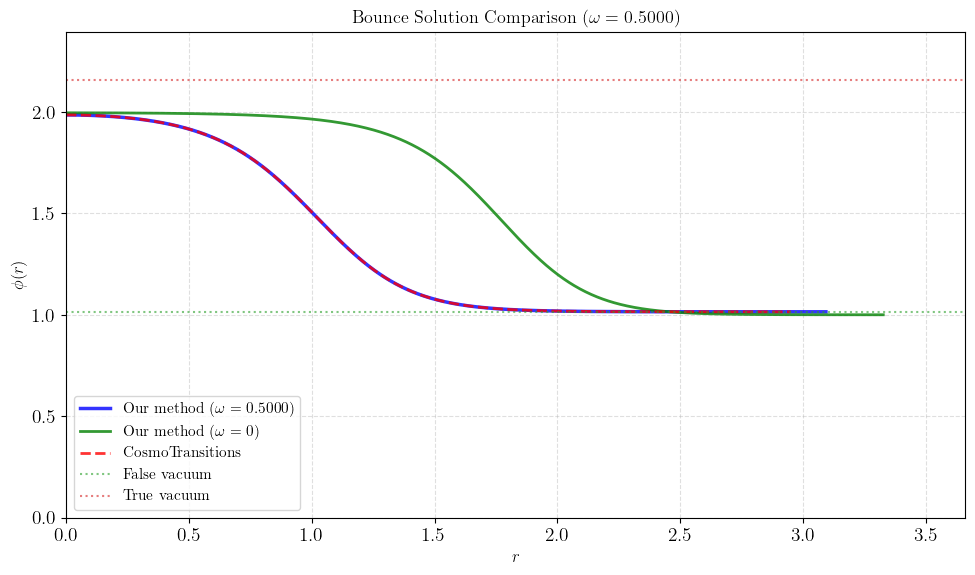

In [13]:
# ============================================================================
# Compare Bounce Solutions: Our Method vs CosmoTransitions
# ============================================================================

import cosmoTransitions.tunneling1D as t1d

# Use the same parameters as the bounce solution above
if r_bounce is not None:
    print("Comparing bounce solutions...")
    print(f"Parameters: φ₀={PHI0_BOUNCE}, v1={V1_BOUNCE}, v2={V2_BOUNCE}, ω={OMEGA_BOUNCE}")
    
    # Get vacua for CosmoTransitions (same as our method)
    phi_false_ct, phi_true_ct = vacua_of_Omega(PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, OMEGA_BOUNCE)
    print(f"Vacua: phi_false={phi_false_ct:.10f}, phi_true={phi_true_ct:.10f}")
    
    # Create potential function for CosmoTransitions
    # CosmoTransitions expects V(phi) where phi is typically a scalar
    def V_Omega(phi):
        """Grand potential Ω(φ) as the effective potential for CosmoTransitions"""
        # Handle both scalar and array inputs
        if np.isscalar(phi):
            return float(Omega_phi(phi, PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, OMEGA_BOUNCE))
        else:
            return np.array([Omega_phi(p, PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, OMEGA_BOUNCE) for p in phi])
    
    def dV_Omega(phi):
        """Derivative of grand potential dΩ/dφ"""
        if np.isscalar(phi):
            return float(dOmega_dphi(phi, PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, OMEGA_BOUNCE))
        else:
            return np.array([dOmega_dphi(p, PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, OMEGA_BOUNCE) for p in phi])
    
    def d2V_Omega(phi):
        """Second derivative of grand potential d²Ω/dφ²"""
        if np.isscalar(phi):
            return float(d2Omega_dphi2(phi, PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, OMEGA_BOUNCE))
        else:
            return np.array([d2Omega_dphi2(p, PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, OMEGA_BOUNCE) for p in phi])
    
    try:
        # Initialize CosmoTransitions instanton
        # phi_absMin = true vacuum (stable, lower energy)
        # phi_metaMin = false vacuum (metastable, higher energy)
        instanton_ct = t1d.SingleFieldInstanton(
            phi_absMin=phi_true_ct,      # True vacuum (stable)
            phi_metaMin=phi_false_ct,    # False vacuum (metastable)
            V=V_Omega,
            dV=dV_Omega,
            d2V=d2V_Omega,
            phi_eps=1e-6,
            alpha=2
        )
        
        # Find the bounce profile
        print("\nComputing bounce solution with CosmoTransitions...")
        R_ct, Phi_ct, dPhi_ct, Rerr_ct = instanton_ct.findProfile(
            npoints=1000,
            phitol=1e-6,
            xtol=1e-6,
            rmin=1e-8,
            rmax=100.0
        )
        
        if R_ct is not None and len(R_ct) > 0:
            print(f"CosmoTransitions solution found:")
            print(f"  φ(0) = {Phi_ct[0]:.6f}")
            print(f"  φ(∞) ≈ {Phi_ct[-1]:.6f} (target false = {phi_false_ct:.6f})")
            print(f"  r_max = {R_ct[-1]:.2f}")
            print(f"  Number of points: {len(R_ct)}")
            if Rerr_ct is not None:
                print(f"  Integration error at r = {Rerr_ct:.2e}")
            
            # Plot comparison
            fig, ax = plt.subplots(figsize=(10, 6))
            
            # Our solution (finite ω)
            ax.plot(r_bounce, phi_bounce, 'b-', lw=2.5, label=f"Our method ($\\omega={OMEGA_BOUNCE:.4f}$)", alpha=0.8)
            
            # Our solution at ω=0 (reference)
            if r_bounce_0 is not None:
                ax.plot(r_bounce_0, phi_bounce_0, 'g-', lw=2, label=r"Our method ($\omega=0$)", alpha=0.8)
            
            # CosmoTransitions solution
            ax.plot(R_ct, Phi_ct, 'r--', lw=2, label="CosmoTransitions", alpha=0.8)
            
            # Vacua lines
            ax.axhline(phi_false_ct, color='C2', ls=':', lw=1.5, label=rf"False vacuum", alpha=0.6)
            ax.axhline(phi_true_ct, color='C3', ls=':', lw=1.5, label=rf"True vacuum", alpha=0.6)
            
            ax.set_xlabel(r"$r$", fontsize=12)
            ax.set_ylabel(r"$\phi(r)$", fontsize=12)
            ax.set_title(rf"Bounce Solution Comparison ($\omega = {OMEGA_BOUNCE:.4f}$)", fontsize=13)
            ax.legend(fontsize=11, loc='best')
            ax.grid(True, ls="--", alpha=0.4)
            
            # Set reasonable limits (include ω=0 curve if present)
            r_max_plot = max(r_bounce[-1], R_ct[-1])
            if r_bounce_0 is not None:
                r_max_plot = max(r_max_plot, r_bounce_0[-1])
            ax.set_xlim(0, min(r_max_plot * 1.1, 20))
            phi_max_plot = max(phi_bounce.max(), Phi_ct.max())
            if r_bounce_0 is not None:
                phi_max_plot = max(phi_max_plot, phi_bounce_0.max())
            ax.set_ylim(0, phi_max_plot * 1.2)
            
            plt.tight_layout()
            plt.show()
            
            
        else:
            print("CosmoTransitions failed to find a solution.")
            
    except Exception as e:
        print(f"Error using CosmoTransitions: {str(e)}")
        import traceback
        traceback.print_exc()
else:
    print("No bounce solution available for comparison. Run the bounce solver cell first.")

## Excess Energy and Excess Charge

For the bounce solution, we compute the **excess energy** $E_{\mathrm{ex}}$ and **excess charge** $Q_{\mathrm{ex}}$ relative to the homogeneous false vacuum background. These quantities characterize the bubble and depend on the chemical potential $\omega$.

**Excess energy** (relative to the false vacuum):
$$E_{\mathrm{ex}} = 4\pi \int_0^{r_{\max}} dr \, r^2 \left[ \frac{1}{2}\left(\frac{d\phi}{dr}\right)^2 + \Omega(\phi) - \Omega(\phi_{\text{false}}) \right]$$

$E_{\mathrm{ex}}$ measures the cost of creating the bubble above the false vacuum. It includes:
- **Kinetic energy**: $\frac{1}{2}\left(\frac{d\phi}{dr}\right)^2$ from the field gradient
- **Potential energy**: $\Omega(\phi) - \Omega(\phi_{\text{false}})$ relative to the false vacuum

**Excess charge** (bubble charge minus background charge in the same volume):
$$Q_{\mathrm{ex}} = 4\pi \int_0^{r_{\max}} dr \, r^2 \left[ q(\rho(r)) - q(\rho_{\mathrm{bg}}) \right] = Q_{\mathrm{bubble}} - V \cdot \omega \phi_{\mathrm{false}}^2$$

where $q(\rho) = \omega \phi^2$ is the charge density, $V = \frac{4}{3}\pi r_{\max}^3$, and $\phi_{\mathrm{false}}(\omega)$ is the false vacuum at that $\omega$. The charge arises from the $-\omega^2\phi^2$ term in the grand potential.

**Physical Interpretation:**

- **Excess energy** $E_{\mathrm{ex}}$: Determines the suppression of the tunneling rate. Higher energy means slower tunneling.
- **Excess charge** $Q_{\mathrm{ex}}$: Measures the charge carried by the bubble relative to the background. As $\omega$ increases, $Q_{\mathrm{ex}}$ typically grows.

In [14]:
# ============================================================================
# Compute Energy and Charge
# ============================================================================

def compute_energy(r, phi, phi0, v1, v2, omega, phi_false):
    """
    Compute energy: E = 4π ∫ dr r² [ ½ (dφ/dr)² + Ω(φ) - Ω(φ_false) ]
    Uses Simpson's rule for better accuracy.
    """
    from scipy.integrate import simpson
    
    # Compute derivative with higher accuracy
    # Use central differences in interior, forward/backward at edges
    dphi_dr = np.gradient(phi, r, edge_order=2)
    dphi_dr[0] = 0.0  # Regularity at origin
    
    # Compute integrand using Omega_phi (consistent with solve_bounce)
    Omega_phi_vals = np.array([Omega_phi(phi_i, phi0, v1, v2, omega) for phi_i in phi])
    Omega_false = Omega_phi(phi_false, phi0, v1, v2, omega)
    
    integrand = 0.5 * dphi_dr**2 + (Omega_phi_vals - Omega_false)
    # Use Simpson's rule for better accuracy
    energy = 4.0 * np.pi * simpson(r**2 * integrand, r)
    return energy

def compute_charge(r, phi, omega):
    """
    Compute charge: Q = 4π ω ∫ dr r² φ²
    Uses Simpson's rule for better accuracy.
    """
    from scipy.integrate import simpson
    # Use Simpson's rule for better accuracy
    integral = simpson(r**2 * phi**2, r)
    return 4.0 * np.pi * omega * integral

def compute_energy_density(r, phi, phi0, v1, v2, omega, phi_false):
    """
    Compute energy density: ρ_E = E/V where
    E = 4π ∫ dr r² [ ½ (dφ/dr)² + Ω(φ) - Ω(φ_false) ]
    V = (4/3)π r_max³
    """
    energy = compute_energy(r, phi, phi0, v1, v2, omega, phi_false)
    r_max = r[-1]
    volume = (4.0 / 3.0) * np.pi * r_max**3
    rho_E = energy / volume
    return rho_E

def compute_charge_density(r, phi, omega):
    """
    Compute charge density: ρ_Q = Q/V where
    Q = 4π ω ∫ dr r² φ²
    V = (4/3)π r_max³
    """
    charge = compute_charge(r, phi, omega)
    r_max = r[-1]
    volume = (4.0 / 3.0) * np.pi * r_max**3
    rho_Q = charge / volume
    return rho_Q

def compute_excess_charge(r, phi, omega, phi_false):
    """
    Excess charge: Q_ex = Q - Q_bg = 4π ∫ dr r² [q(ρ(r)) - q(ρ_bg)]
    with q(ρ_bg) = ω φ_false² over the same volume.
    """
    Q = compute_charge(r, phi, omega)
    r_max = r[-1]
    V = (4.0 / 3.0) * np.pi * r_max**3
    Q_bg = V * (omega * phi_false**2)
    return Q - Q_bg

def compute_excess_energy(r, phi, phi0, v1, v2, omega, phi_false):
    """
    Excess energy: E_ex = E (already relative to false vacuum Ω(φ_false)).
    E_ex = 4π ∫ dr r² [ε(ρ(r)) - ε(ρ_bg)] with ε(ρ_bg) = 0.
    """
    return compute_energy(r, phi, phi0, v1, v2, omega, phi_false)

if r_bounce is not None:
    # Use the bounce parameters: excess energy and excess charge (relative to background)
    E_ex_bounce = compute_excess_energy(r_bounce, phi_bounce, PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, OMEGA_BOUNCE, phi_false_bounce)
    Q_ex_bounce = compute_excess_charge(r_bounce, phi_bounce, OMEGA_BOUNCE, phi_false_bounce)
    
    print(f"Bounce solution observables (excess over background):")
    print(f"  Excess energy: E_ex = {E_ex_bounce:.6f}")
    print(f"  Excess charge: Q_ex = {Q_ex_bounce:.6f}")
    print(f"  E_ex/Q_ex = {E_ex_bounce/Q_ex_bounce:.6f}")

    # Reference: bounce at ω=0 (excess energy only; Q_ex=0 at ω=0)
    if r_bounce_0 is not None:
        E_ex_bounce_0 = compute_excess_energy(r_bounce_0, phi_bounce_0, PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, 0.0, phi_false_bounce_0)
        print(f"\nReference (ω=0): E_ex = {E_ex_bounce_0:.6f}  (Q_ex=0 at ω=0)")

    # Compute excess energy and excess charge for both solutions
    print("\nComputing observables for both solutions...")
            
    # Our method
    E_ex_ours = compute_excess_energy(r_bounce, phi_bounce, PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, OMEGA_BOUNCE, phi_false_ct)
    Q_ex_ours = compute_excess_charge(r_bounce, phi_bounce, OMEGA_BOUNCE, phi_false_ct)
            
    # CosmoTransitions solution
    E_ex_ct = compute_excess_energy(R_ct, Phi_ct, PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, OMEGA_BOUNCE, phi_false_ct)
    Q_ex_ct = compute_excess_charge(R_ct, Phi_ct, OMEGA_BOUNCE, phi_false_ct)
            
    # Print comparison statistics
    print(f"\n{'='*70}")
    print(f"Solution Comparison (excess E_ex, Q_ex):")
    print(f"{'='*70}")
    print(f"\nField values:")
    print(f"  Our method:      φ(0)={phi0_bounce:.6f}, φ(∞)={phi_bounce[-1]:.6f}, r_max={r_bounce[-1]:.2f}")
    print(f"  CosmoTransitions: φ(0)={Phi_ct[0]:.6f}, φ(∞)={Phi_ct[-1]:.6f}, r_max={R_ct[-1]:.2f}")
    print(f"  Difference:      Δφ(0)={abs(phi0_bounce - Phi_ct[0]):.6e}, Δφ(∞)={abs(phi_bounce[-1] - Phi_ct[-1]):.6e}")
            
    print(f"\nExcess energy E_ex:")
    print(f"  Our method:      E_ex = {E_ex_ours:.6f}")
    print(f"  CosmoTransitions: E_ex = {E_ex_ct:.6f}")
    print(f"  Difference:      ΔE_ex = {abs(E_ex_ours - E_ex_ct):.6e}")
    print(f"  Relative diff:   ΔE_ex/E_ex = {abs(E_ex_ours - E_ex_ct)/max(abs(E_ex_ours), abs(E_ex_ct)):.2e}")
            
    print(f"\nExcess charge Q_ex:")
    print(f"  Our method:      Q_ex = {Q_ex_ours:.6f}")
    print(f"  CosmoTransitions: Q_ex = {Q_ex_ct:.6f}")
    print(f"  Difference:      ΔQ_ex = {abs(Q_ex_ours - Q_ex_ct):.6e}")
    print(f"  Relative diff:   ΔQ_ex/Q_ex = {abs(Q_ex_ours - Q_ex_ct)/max(abs(Q_ex_ours), abs(Q_ex_ct)):.2e}")
            
    print(f"\nE_ex/Q_ex ratio:")
    print(f"  Our method:      E_ex/Q_ex = {E_ex_ours/Q_ex_ours:.6f}")
    print(f"  CosmoTransitions: E_ex/Q_ex = {E_ex_ct/Q_ex_ct:.6f}")
    print(f"  Difference:      Δ(E_ex/Q_ex) = {abs(E_ex_ours/Q_ex_ours - E_ex_ct/Q_ex_ct):.6e}")
    print(f"{'='*70}")

Bounce solution observables (excess over background):
  Excess energy: E_ex = 3.624620
  Excess charge: Q_ex = 6.959327
  E_ex/Q_ex = 0.520829

Reference (ω=0): E_ex = 11.321257  (Q_ex=0 at ω=0)

Computing observables for both solutions...

Solution Comparison (excess E_ex, Q_ex):

Field values:
  Our method:      φ(0)=1.984625, φ(∞)=1.014643, r_max=3.09
  CosmoTransitions: φ(0)=1.984617, φ(∞)=1.014677, r_max=2.95
  Difference:      Δφ(0)=7.285997e-06, Δφ(∞)=3.362952e-05

Excess energy E_ex:
  Our method:      E_ex = 3.624620
  CosmoTransitions: E_ex = 3.624630
  Difference:      ΔE_ex = 9.546279e-06
  Relative diff:   ΔE_ex/E_ex = 2.63e-06

Excess charge Q_ex:
  Our method:      Q_ex = 6.959327
  CosmoTransitions: Q_ex = 6.958982
  Difference:      ΔQ_ex = 3.445898e-04
  Relative diff:   ΔQ_ex/Q_ex = 4.95e-05

E_ex/Q_ex ratio:
  Our method:      E_ex/Q_ex = 0.520829
  CosmoTransitions: E_ex/Q_ex = 0.520856
  Difference:      Δ(E_ex/Q_ex) = 2.716183e-05


## Excess Charge and Excess Energy vs Omega Scan

We scan over the chemical potential $\omega$ to study how the bubble solution depends on finite density effects. The bounce solution exists only when the grand potential $\Omega(\phi) = V(\phi) - \omega^2\phi^2$ has two distinct minima.

**Range of Validity:**

- $\omega_{\min} = 0$: At zero chemical potential, we recover the standard vacuum decay case. The analytical action $S_0$ provides a reference for $d=4$ and $Q=0$.
- $\omega_{\max}$: Maximum value where two minima still exist. Beyond this, the $\omega^2$ term becomes too large and destroys one of the minima, making tunneling impossible.

**Adaptive r₀ Selection:**

For each $\omega$, we use an adaptive binary search to find the optimal initial radius $r_0$:
- Start from $r_0 = 10^{-10}$ (very small, needed for small $\omega$)
- If the solution doesn't converge (either $|\phi(\infty) - \phi_{\text{false}}| > 10^{-3}$ or $|\phi'(\infty)| > 10^{-3}$), we increase $r_0$
- Use binary search to find the smallest $r_0$ that gives a convergent solution
- This ensures accurate solutions for both small and large values of $\omega$

**Output:**

For each $\omega$ in the valid range, we compute:
- The bounce solution $\phi(r)$
- Excess charge $Q_{\mathrm{ex}}(\omega)$ (bubble charge minus background charge)
- Excess energy $E_{\mathrm{ex}}(\omega)$ (relative to the false vacuum)

These quantities show how finite density (non-zero $\omega$) affects the bubble nucleation process.

In [15]:
# ============================================================================
# Find Omega Range with Two Minima *and a Barrier*
# ============================================================================

def has_barrier(phi0, v1, v2, omega, n_grid=400, barrier_tol=1e-6):
    """Return True if Ω(φ) has two distinct local minima separated by a barrier."""
    try:
        phi_false, phi_true = vacua_of_Omega(phi0, v1, v2, omega)
    except RuntimeError:
        return False

    # Ensure distinct minima
    if abs(phi_true - phi_false) < 1e-4:
        return False

    a, b = (phi_false, phi_true) if phi_false < phi_true else (phi_true, phi_false)
    Om_a = Omega_phi(a, phi0, v1, v2, omega)
    Om_b = Omega_phi(b, phi0, v1, v2, omega)

    # Sample Ω between the minima and require an interior maximum above both minima
    grid = np.linspace(a, b, n_grid)
    Om = np.array([Omega_phi(x, phi0, v1, v2, omega) for x in grid])
    i_max = int(np.argmax(Om))

    # Maximum must be in the interior (otherwise no barrier between the minima)
    if i_max == 0 or i_max == len(grid) - 1:
        return False

    Om_max = Om[i_max]
    if Om_max - max(Om_a, Om_b) <= barrier_tol:
        return False

    return True

# ============================================================================
# Scan Parameters
# ============================================================================
SCAN_RMAX = 1000.0        # Maximum integration radius for scan
SCAN_MAX_ITER = 150       # Maximum bisection iterations for scan
SCAN_N_POINTS = 100       # Number of omega points in scan (increased for smoother curves)
SCAN_GRID_POINTS = 3000   # Number of points in solution grid (increased for better integration)
SCAN_R0 = 1e-8            # Fixed r0 value for all solutions

# Find ω_max where the barrier disappears
print("Finding maximum omega with a tunneling barrier...")
omega_test = np.linspace(0.0, 2.0, 400)
omega_lo = 0.0
omega_hi = None

for om in omega_test:
    if has_barrier(phi0, v1, v2, om):
        omega_lo = om
    else:
        omega_hi = om
        break

if omega_hi is None:
    omega_hi = omega_test[-1]

# Refine with bisection
for _ in range(35):
    om_mid = 0.5 * (omega_lo + omega_hi)
    if has_barrier(phi0, v1, v2, om_mid):
        omega_lo = om_mid
    else:
        omega_hi = om_mid

omega_max = omega_lo
print(f"Omega range with tunneling barrier: [0, {omega_max:.6f}]")

# Scan over omega
print(f"\nScanning over omega in [0, {omega_max:.6f}]...")
print(f"Scan parameters: RMAX={SCAN_RMAX}, max_iter={SCAN_MAX_ITER}, n_points={SCAN_N_POINTS}, r0={SCAN_R0}")
n_omega = SCAN_N_POINTS
omega_scan = np.linspace(0.01, omega_max * 0.98, n_omega)  # stay away from ω_max
Q_vals = []   # will store Q_ex (excess charge)
E_vals = []   # will store E_ex (excess energy)
Q_tot_vals = []  # will store total Q (no background subtraction)
E_tot_vals = []  # will store total E (no background subtraction)
omega_valid = []
r_max_vals = []  # r_max of each solution (for volume correction)
phi_false_vals = []  # phi_false at each omega (for volume correction)

for i, om in enumerate(omega_scan):
    if i % 10 == 0:
        print(f"  Processing omega = {om:.6f} ({i+1}/{n_omega})...")
    
    try:
        # Solve bounce with fixed r0
        r_b, phi_b, phi0_b, phi_false_om, phi_true_om = solve_bounce(
            phi0, v1, v2, om, 
            d=3, r0=SCAN_R0, rmax=SCAN_RMAX, 
            max_iter=SCAN_MAX_ITER, verbose=False,
            n_grid_points=SCAN_GRID_POINTS
        )
        
        if r_b is not None and len(r_b) > 10:
            # Check convergence (avoid np.gradient warnings if r-grid is degenerate)
            if (r_b[-1] - r_b[0]) <= 1e-12:
                if i % 10 == 0:
                    print(f"    r-range too small (r_end≈r0). Skipping omega = {om:.6f}")
                continue

            phi_end = phi_b[-1]
            dphi_dr = np.gradient(phi_b, r_b, edge_order=2)
            dphi_end = dphi_dr[-1]
            phi_error = abs(phi_end - phi_false_om)
            dphi_error = abs(dphi_end)
            
            if phi_error < 1e-3 and dphi_error < 1e-3:
                # Ensure r-grid is strictly increasing and has sufficient points
                if len(r_b) < 50:
                    if i % 10 == 0:
                        print(f"    Solution has too few points ({len(r_b)}). Skipping.")
                    continue
                
                # Remove duplicate r values if any (can cause integration issues)
                r_unique, idx_unique = np.unique(r_b, return_index=True)
                if len(r_unique) < len(r_b):
                    r_b = r_b[idx_unique]
                    phi_b = phi_b[idx_unique]
                
                Q_ex = compute_excess_charge(r_b, phi_b, om, phi_false_om)
                E_ex = compute_excess_energy(r_b, phi_b, phi0, v1, v2, om, phi_false_om)
                Q_vals.append(Q_ex)
                E_vals.append(E_ex)

                # Also store total (non-excess) observables and r_max for volume correction
                Q_tot = compute_charge(r_b, phi_b, om)
                E_tot = compute_energy(r_b, phi_b, phi0, v1, v2, om, phi_false_om)
                Q_tot_vals.append(Q_tot)
                E_tot_vals.append(E_tot)
                r_max_vals.append(r_b[-1])
                phi_false_vals.append(phi_false_om)

                omega_valid.append(om)
                if i % 10 == 0:
                    print(f"    Converged (φ error: {phi_error:.2e}, φ' error: {dphi_error:.2e})")
            else:
                if i % 10 == 0:
                    print(f"    Solution found but not success (φ error: {phi_error:.2e}, φ' error: {dphi_error:.2e})")
        else:
            if i % 10 == 0:
                print(f"    No valid solution found for omega = {om:.6f}")
    except (RuntimeError, ValueError) as e:
        if i % 10 == 0:
            print(f"    Error solving for omega = {om:.6f}: {str(e)[:50]}")

Q_vals = np.array(Q_vals)
E_vals = np.array(E_vals)
Q_tot_vals = np.array(Q_tot_vals)
E_tot_vals = np.array(E_tot_vals)
omega_valid = np.array(omega_valid)
r_max_vals = np.array(r_max_vals)
phi_false_vals = np.array(phi_false_vals)

# Volume correction: bring E_tot and Q_tot to common r_max = min(r_max) so all points comparable
r_max_min = r_max_vals.min()
V_min = (4.0 / 3.0) * np.pi * r_max_min**3
for i in range(len(omega_valid)):
    V_each = (4.0 / 3.0) * np.pi * r_max_vals[i]**3
    dV = V_min - V_each  # positive when r_max_each > r_max_min
    # Charge in shell (false vacuum): add omega*phi_false^2*dV to get Q at common volume
    Q_tot_vals[i] += omega_valid[i] * phi_false_vals[i]**2 * dV
    # E_tot_vals is excess energy (Ω(φ)-Ω(φ_false)); integrand in shell is 0, so no E correction needed
print(f"Volume correction applied: r_max_min = {r_max_min:.4f} (Q_tot at common volume; E is excess, no correction)")

print(f"\nScan complete: {len(omega_valid)} successful solutions")

Finding maximum omega with a tunneling barrier...
Omega range with tunneling barrier: [0, 0.935223]

Scanning over omega in [0, 0.935223]...
Scan parameters: RMAX=1000.0, max_iter=150, n_points=100, r0=1e-08
  Processing omega = 0.010000 (1/100)...
    Converged (φ error: 4.78e-05, φ' error: 1.21e-08)
  Processing omega = 0.101568 (11/100)...
    Converged (φ error: 3.12e-05, φ' error: 1.74e-08)
  Processing omega = 0.193135 (21/100)...
    Converged (φ error: 1.81e-05, φ' error: 1.12e-08)
  Processing omega = 0.284703 (31/100)...
    Converged (φ error: 1.46e-05, φ' error: 1.77e-08)
  Processing omega = 0.376270 (41/100)...
    Converged (φ error: 0.00e+00, φ' error: 1.48e-04)
  Processing omega = 0.467838 (51/100)...
    Converged (φ error: 0.00e+00, φ' error: 6.07e-05)
  Processing omega = 0.559405 (61/100)...
    Converged (φ error: 0.00e+00, φ' error: 3.35e-05)
  Processing omega = 0.650973 (71/100)...
    Converged (φ error: 2.46e-06, φ' error: 4.07e-09)
  Processing omega = 0.74

### Excess Charge and Excess Energy vs Omega Plot

The excess charge $Q_{\mathrm{ex}}(\omega)$ and excess energy $E_{\mathrm{ex}}(\omega)$ show how the bubble solution depends on the chemical potential $\omega$.

**Key Features:**

- **At $\omega = 0$**: There is no excess charge ($Q_{\mathrm{ex}} = 0$), and we recover the standard vacuum decay. The excess energy $E_{\mathrm{ex}}$ at $\omega = 0$ can be compared with the analytical action $S_0$ for $d=4$ (though we compute in $d=3$ here).

- **As $\omega$ increases**: 
  - The excess charge $Q_{\mathrm{ex}}(\omega)$ typically grows, indicating that the bubble carries more charge relative to the background
  - The excess energy $E_{\mathrm{ex}}(\omega)$ changes, showing how finite density affects the tunneling barrier
  - The grand potential $\Omega(\phi)$ is increasingly modified, shifting the minima away from $\phi = 1$ and $\phi = 2$

- **At $\omega_{\max}$**: The maximum value where two minima still exist. Beyond this point, the $\omega^2$ term becomes dominant and destroys the barrier between vacua.

**Physical Interpretation:**

The curves $Q_{\mathrm{ex}}(\omega)$ and $E_{\mathrm{ex}}(\omega)$ characterize how finite density (non-zero chemical potential) modifies the bubble nucleation process. This is relevant for understanding vacuum decay in environments with finite particle density, such as in early universe cosmology or high-density matter systems.

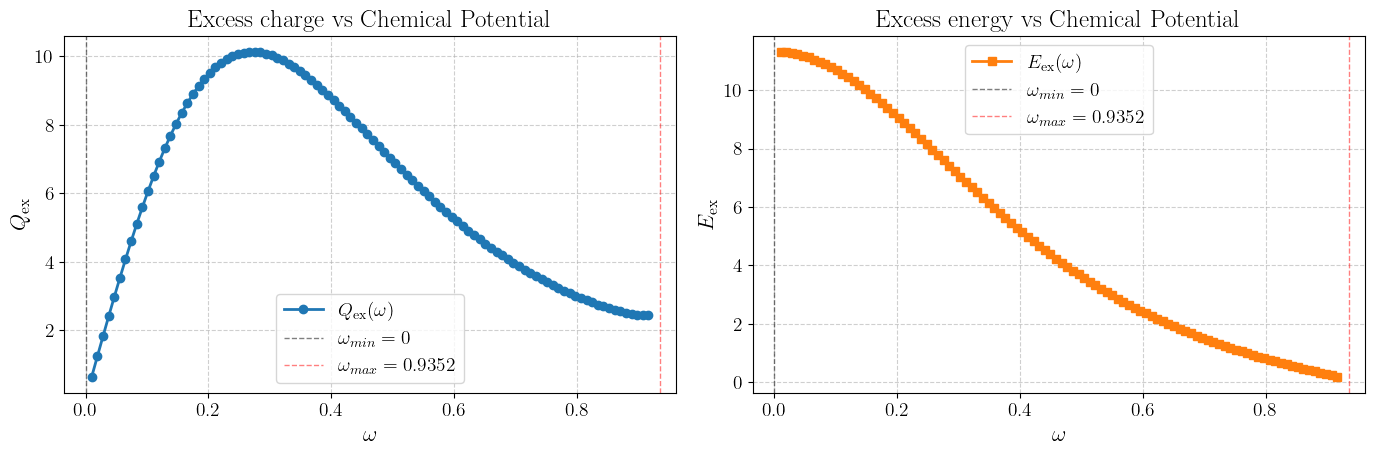


Summary:
  ω range (barrier): [0, 0.9352]
  Q_ex range: [0.6486, 10.13]
  E_ex range: [0.1916, 11.32]


In [16]:
# Plot excess charge Q_ex(ω) and excess energy E_ex(ω)
if len(omega_valid) > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.8))
    
    # Excess charge vs omega
    ax1.plot(omega_valid, Q_vals, 'o-', lw=2, markersize=6, color='C0', label=r"$Q_{\mathrm{ex}}(\omega)$")
    ax1.set_xlabel(r"$\omega$")
    ax1.set_ylabel(r"$Q_{\mathrm{ex}}$")
    ax1.set_title("Excess charge vs Chemical Potential")
    ax1.axvline(0, color='k', ls='--', lw=1, alpha=0.5, label=rf"$\omega_{{min}} = 0$")
    ax1.axvline(omega_max, color='r', ls='--', lw=1, alpha=0.5, label=rf"$\omega_{{max}} = {omega_max:.4f}$")
    ax1.legend()
    ax1.grid(True, ls="--", alpha=0.6)
    
    # Excess energy vs omega
    ax2.plot(omega_valid, E_vals, 's-', lw=2, markersize=6, color='C1', label=r"$E_{\mathrm{ex}}(\omega)$")
    ax2.set_xlabel(r"$\omega$")
    ax2.set_ylabel(r"$E_{\mathrm{ex}}$")
    ax2.set_title("Excess energy vs Chemical Potential")
    ax2.axvline(0, color='k', ls='--', lw=1, alpha=0.5, label=rf"$\omega_{{min}} = 0$")
    ax2.axvline(omega_max, color='r', ls='--', lw=1, alpha=0.5, label=rf"$\omega_{{max}} = {omega_max:.4f}$")
    ax2.legend()
    ax2.grid(True, ls="--", alpha=0.6)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nSummary:")
    print(f"  ω range (barrier): [0, {omega_max:.4f}]")
    print(f"  Q_ex range: [{Q_vals.min():.4g}, {Q_vals.max():.4g}]")
    print(f"  E_ex range: [{E_vals.min():.4g}, {E_vals.max():.4g}]")
else:
    print("No valid solutions found for plotting.")

### Excess Charge and Excess Energy vs Omega Scan (CosmoTransitions)

We perform the same scan over $\omega$ using CosmoTransitions to compare with our method. For each $\omega$ we compute excess charge $Q_{\mathrm{ex}}$ and excess energy $E_{\mathrm{ex}}$ (relative to the homogeneous background). This allows us to verify the consistency of the two approaches and identify any systematic differences.

In [17]:
# ============================================================================
# Omega Scan using CosmoTransitions
# ============================================================================

SCAN_N_POINTS = 100

import cosmoTransitions.tunneling1D as t1d

# Use the same omega_max and scan parameters from the previous scan
# (omega_max should be defined in cell 13)
if 'omega_max' in globals() and omega_max > 0:
    print("Scanning over omega using CosmoTransitions...")
    print(f"Omega range: [0, {omega_max:.6f}]")
    print(f"Scan parameters: n_points={SCAN_N_POINTS}")
    
    n_omega_ct = SCAN_N_POINTS
    omega_scan_ct = np.linspace(0.01, omega_max * 0.98, n_omega_ct)
    Q_vals_ct = []   # will store Q_ex (excess charge)
    E_vals_ct = []   # will store E_ex (excess energy)
    Q_tot_vals_ct = []  # will store total Q (no background subtraction)
    E_tot_vals_ct = []  # will store total E (no background subtraction)
    omega_valid_ct = []
    r_max_vals_ct = []  # r_max of each solution (for volume correction)
    phi_false_vals_ct = []  # phi_false at each omega (for volume correction)
    
    for i, om in enumerate(omega_scan_ct):
        if i % 10 == 0:
            print(f"  Processing omega = {om:.6f} ({i+1}/{n_omega_ct})...")
        
        try:
            # Get vacua for this omega
            phi_false_ct, phi_true_ct = vacua_of_Omega(phi0, v1, v2, om)
            
            # Create potential functions for CosmoTransitions
            def V_Omega_scan(phi):
                """Grand potential Ω(φ) for scan"""
                if np.isscalar(phi):
                    return float(Omega_phi(phi, phi0, v1, v2, om))
                else:
                    return np.array([Omega_phi(p, phi0, v1, v2, om) for p in phi])
            
            def dV_Omega_scan(phi):
                """Derivative of grand potential dΩ/dφ for scan"""
                if np.isscalar(phi):
                    return float(dOmega_dphi(phi, phi0, v1, v2, om))
                else:
                    return np.array([dOmega_dphi(p, phi0, v1, v2, om) for p in phi])
            
            def d2V_Omega_scan(phi):
                """Second derivative of grand potential d²Ω/dφ² for scan"""
                if np.isscalar(phi):
                    return float(d2Omega_dphi2(phi, phi0, v1, v2, om))
                else:
                    return np.array([d2Omega_dphi2(p, phi0, v1, v2, om) for p in phi])
            
            # Initialize CosmoTransitions instanton
            instanton_ct = t1d.SingleFieldInstanton(
                phi_absMin=phi_true_ct,      # True vacuum (stable)
                phi_metaMin=phi_false_ct,    # False vacuum (metastable)
                V=V_Omega_scan,
                dV=dV_Omega_scan,
                d2V=d2V_Omega_scan,
                phi_eps=1e-6,
                alpha=2
            )
            
            # Find the bounce profile
            R_ct, Phi_ct, dPhi_ct, Rerr_ct = instanton_ct.findProfile(
                npoints=SCAN_GRID_POINTS,
                phitol=1e-6,
                xtol=1e-6,
                rmin=1e-8,
                rmax=SCAN_RMAX
            )
            
            if R_ct is not None and len(R_ct) > 50:
                # Check convergence
                phi_end = Phi_ct[-1]
                phi_error = abs(phi_end - phi_false_ct)
                
                if phi_error < 1e-3:
                    # Remove duplicate r values if any
                    R_unique, idx_unique = np.unique(R_ct, return_index=True)
                    if len(R_unique) < len(R_ct):
                        R_ct = R_ct[idx_unique]
                        Phi_ct = Phi_ct[idx_unique]
                    
                    # Compute excess charge and excess energy
                    Q_ex_ct = compute_excess_charge(R_ct, Phi_ct, om, phi_false_ct)
                    E_ex_ct = compute_excess_energy(R_ct, Phi_ct, phi0, v1, v2, om, phi_false_ct)
                    
                    Q_vals_ct.append(Q_ex_ct)
                    E_vals_ct.append(E_ex_ct)

                    # Also store total (non-excess) observables and r_max for volume correction
                    Q_tot_ct = compute_charge(R_ct, Phi_ct, om)
                    E_tot_ct = compute_energy(R_ct, Phi_ct, phi0, v1, v2, om, phi_false_ct)
                    Q_tot_vals_ct.append(Q_tot_ct)
                    E_tot_vals_ct.append(E_tot_ct)
                    r_max_vals_ct.append(R_ct[-1])
                    phi_false_vals_ct.append(phi_false_ct)
                    omega_valid_ct.append(om)
                    
                    if i % 10 == 0:
                        print(f"    Converged (φ error: {phi_error:.2e})")
                else:
                    if i % 10 == 0:
                        print(f"    Solution found but not success (φ error: {phi_error:.2e})")
            else:
                if i % 10 == 0:
                    print(f"    No valid solution found for omega = {om:.6f}")
                    
        except Exception as e:
            if i % 10 == 0:
                print(f"    Error solving for omega = {om:.6f}: {str(e)[:60]}")
    
    Q_vals_ct = np.array(Q_vals_ct)
    E_vals_ct = np.array(E_vals_ct)
    Q_tot_vals_ct = np.array(Q_tot_vals_ct)
    E_tot_vals_ct = np.array(E_tot_vals_ct)
    omega_valid_ct = np.array(omega_valid_ct)
    r_max_vals_ct = np.array(r_max_vals_ct)
    phi_false_vals_ct = np.array(phi_false_vals_ct)
    
    # Volume correction: bring E_tot and Q_tot to common r_max = min(r_max) so all points comparable
    r_max_min_ct = r_max_vals_ct.min()
    V_min_ct = (4.0 / 3.0) * np.pi * r_max_min_ct**3
    for i in range(len(omega_valid_ct)):
        V_each = (4.0 / 3.0) * np.pi * r_max_vals_ct[i]**3
        dV = V_min_ct - V_each
        Q_tot_vals_ct[i] += omega_valid_ct[i] * phi_false_vals_ct[i]**2 * dV
        # E_tot_vals_ct is excess energy; integrand in shell is 0, so no E correction needed
    print(f"Volume correction applied (CT): r_max_min = {r_max_min_ct:.4f} (Q_tot at common volume; E is excess, no correction)")
    
    print(f"\nCosmoTransitions scan complete: {len(omega_valid_ct)} successful solutions")
else:
    print("Error: omega_max not defined. Please run the scan cell (cell 13) first.")
    Q_vals_ct = np.array([])
    E_vals_ct = np.array([])
    Q_tot_vals_ct = np.array([])
    E_tot_vals_ct = np.array([])
    omega_valid_ct = np.array([])
    r_max_vals_ct = np.array([])
    phi_false_vals_ct = np.array([])

Scanning over omega using CosmoTransitions...
Omega range: [0, 0.935223]
Scan parameters: n_points=100
  Processing omega = 0.010000 (1/100)...
    Converged (φ error: 2.22e-16)


/home/giulio/Madrid - PostDoc/Projects/Finite Density Vacuum decay/.venv/lib/python3.12/site-packages/cosmoTransitions/tunneling1D.py:421: RuntimeWarning: overflow encountered in scalar multiply
  r *= 10
/home/giulio/Madrid - PostDoc/Projects/Finite Density Vacuum decay/.venv/lib/python3.12/site-packages/cosmoTransitions/tunneling1D.py:421: RuntimeWarning: overflow encountered in scalar multiply
  r *= 10


  Processing omega = 0.101568 (11/100)...
    Converged (φ error: 4.76e-05)
  Processing omega = 0.193135 (21/100)...
    Converged (φ error: 2.22e-16)
  Processing omega = 0.284703 (31/100)...
    Converged (φ error: 1.04e-05)
  Processing omega = 0.376270 (41/100)...
    Converged (φ error: 6.81e-05)
  Processing omega = 0.467838 (51/100)...
    Converged (φ error: 5.93e-05)
  Processing omega = 0.559405 (61/100)...
    Converged (φ error: 7.98e-05)
  Processing omega = 0.650973 (71/100)...
    Converged (φ error: 0.00e+00)
  Processing omega = 0.742540 (81/100)...
    Converged (φ error: 2.22e-16)
  Processing omega = 0.834108 (91/100)...
    Converged (φ error: 2.22e-16)
Volume correction applied (CT): r_max_min = 2.7090 (Q_tot at common volume; E is excess, no correction)

CosmoTransitions scan complete: 98 successful solutions


### Excess Charge and Excess Energy vs Omega Plot (CosmoTransitions)

Comparison of the excess charge $Q_{\mathrm{ex}}(\omega)$ and excess energy $E_{\mathrm{ex}}(\omega)$ computed using CosmoTransitions. These should match closely with our method, providing a cross-check of the numerical accuracy.

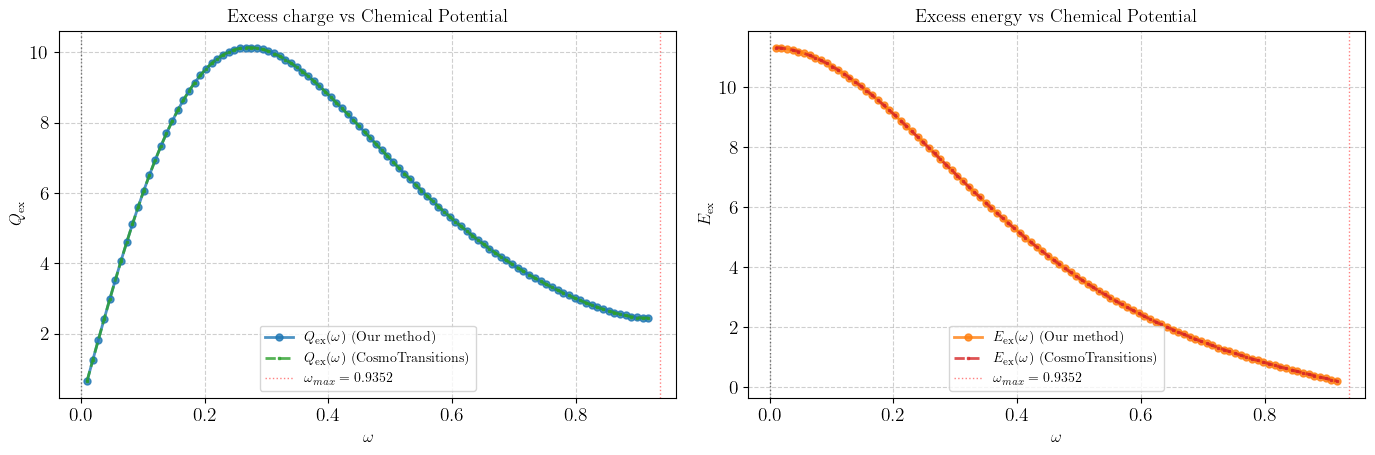


Scan Results Summary

Our method:
  ω range (barrier): [0, 0.9352]
  Successful solutions: 100
  Q_ex range: [0.6486, 10.13]
  E_ex range: [0.1916, 11.32]

CosmoTransitions:
  ω range (barrier): [0, 0.9352]
  Successful solutions: 98
  Q_ex range: [0.6486, 10.13]
  E_ex range: [0.1916, 11.32]

Comparison Statistics
  Our method:      100 successful solutions
  CosmoTransitions: 98 successful solutions

  At 98 overlapping points:
    Mean |ΔQ_ex| = 8.534209e-04
    Mean |ΔE_ex| = 4.330352e-06
    Max |ΔQ_ex| = 4.448260e-03
    Max |ΔE_ex| = 1.691048e-05
    Mean relative |ΔQ_ex/Q_ex| = 1.88e-04
    Mean relative |ΔE_ex/E_ex| = 9.49e-07


In [18]:
# Plot excess charge Q_ex(ω) and excess energy E_ex(ω) (Comparison: Our Method vs CosmoTransitions)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.8))

# Check if we have both datasets
has_ours = 'omega_valid' in globals() and len(omega_valid) > 0
has_ct = len(omega_valid_ct) > 0

if has_ours or has_ct:
    # Excess charge vs omega
    if has_ours:
        ax1.plot(omega_valid, Q_vals, 'o-', lw=2, markersize=5, color='C0', 
                label=r"$Q_{\mathrm{ex}}(\omega)$ (Our method)", alpha=0.8)
    if has_ct:
        ax1.plot(omega_valid_ct, Q_vals_ct, 's--', lw=2, markersize=2, color='C2', 
                label=r"$Q_{\mathrm{ex}}(\omega)$ (CosmoTransitions)", alpha=0.8)
    ax1.set_xlabel(r"$\omega$", fontsize=12)
    ax1.set_ylabel(r"$Q_{\mathrm{ex}}$", fontsize=12)
    ax1.set_title("Excess charge vs Chemical Potential", fontsize=13)
    ax1.axvline(0, color='k', ls=':', lw=1, alpha=0.5)
    ax1.axvline(omega_max, color='r', ls=':', lw=1, alpha=0.5, label=rf"$\omega_{{max}} = {omega_max:.4f}$")
    ax1.legend(fontsize=10, loc='best')
    ax1.grid(True, ls="--", alpha=0.6)
    
    # Excess energy vs omega
    if has_ours:
        ax2.plot(omega_valid, E_vals, 'o-', lw=2, markersize=5, color='C1', 
                label=r"$E_{\mathrm{ex}}(\omega)$ (Our method)", alpha=0.8)
    if has_ct:
        ax2.plot(omega_valid_ct, E_vals_ct, 's--', lw=2, markersize=2, color='C3', 
                label=r"$E_{\mathrm{ex}}(\omega)$ (CosmoTransitions)", alpha=0.8)
    ax2.set_xlabel(r"$\omega$", fontsize=12)
    ax2.set_ylabel(r"$E_{\mathrm{ex}}$", fontsize=12)
    ax2.set_title("Excess energy vs Chemical Potential", fontsize=13)
    ax2.axvline(0, color='k', ls=':', lw=1, alpha=0.5)
    ax2.axvline(omega_max, color='r', ls=':', lw=1, alpha=0.5, label=rf"$\omega_{{max}} = {omega_max:.4f}$")
    ax2.legend(fontsize=10, loc='best')
    ax2.grid(True, ls="--", alpha=0.6)
    
    plt.tight_layout()
    plt.show()
    
    # Print summaries
    print(f"\n{'='*70}")
    print(f"Scan Results Summary")
    print(f"{'='*70}")
    
    if has_ours:
        print(f"\nOur method:")
        print(f"  ω range (barrier): [0, {omega_max:.4f}]")
        print(f"  Successful solutions: {len(omega_valid)}")
        print(f"  Q_ex range: [{Q_vals.min():.4g}, {Q_vals.max():.4g}]")
        print(f"  E_ex range: [{E_vals.min():.4g}, {E_vals.max():.4g}]")
    
    if has_ct:
        print(f"\nCosmoTransitions:")
        print(f"  ω range (barrier): [0, {omega_max:.4f}]")
        print(f"  Successful solutions: {len(omega_valid_ct)}")
        print(f"  Q_ex range: [{Q_vals_ct.min():.4g}, {Q_vals_ct.max():.4g}]")
        print(f"  E_ex range: [{E_vals_ct.min():.4g}, {E_vals_ct.max():.4g}]")
    
    # Compare with our method if available
    if has_ours and has_ct:
        print(f"\n{'='*70}")
        print(f"Comparison Statistics")
        print(f"{'='*70}")
        print(f"  Our method:      {len(omega_valid)} successful solutions")
        print(f"  CosmoTransitions: {len(omega_valid_ct)} successful solutions")
        
        # Find overlapping omega values for direct comparison
        from scipy.interpolate import interp1d
        
        try:
            # Interpolate our results to CosmoTransitions omega values
            Q_interp = interp1d(omega_valid, Q_vals, kind='linear', bounds_error=False, fill_value=np.nan)
            E_interp = interp1d(omega_valid, E_vals, kind='linear', bounds_error=False, fill_value=np.nan)
            
            # Compare at overlapping points
            Q_ours_at_ct = Q_interp(omega_valid_ct)
            E_ours_at_ct = E_interp(omega_valid_ct)
            
            # Find valid comparisons (where both have values)
            valid_mask = ~(np.isnan(Q_ours_at_ct) | np.isnan(E_ours_at_ct))
            if np.any(valid_mask):
                omega_compare = omega_valid_ct[valid_mask]
                Q_diff = Q_vals_ct[valid_mask] - Q_ours_at_ct[valid_mask]
                E_diff = E_vals_ct[valid_mask] - E_ours_at_ct[valid_mask]
                
                print(f"\n  At {np.sum(valid_mask)} overlapping points:")
                print(f"    Mean |ΔQ_ex| = {np.mean(np.abs(Q_diff)):.6e}")
                print(f"    Mean |ΔE_ex| = {np.mean(np.abs(E_diff)):.6e}")
                print(f"    Max |ΔQ_ex| = {np.max(np.abs(Q_diff)):.6e}")
                print(f"    Max |ΔE_ex| = {np.max(np.abs(E_diff)):.6e}")
                
                # Relative differences
                Q_ours_valid = Q_ours_at_ct[valid_mask]
                E_ours_valid = E_ours_at_ct[valid_mask]
                Q_rel_diff = np.abs(Q_diff) / (np.abs(Q_ours_valid) + 1e-10)
                E_rel_diff = np.abs(E_diff) / (np.abs(E_ours_valid) + 1e-10)
                print(f"    Mean relative |ΔQ_ex/Q_ex| = {np.mean(Q_rel_diff):.2e}")
                print(f"    Mean relative |ΔE_ex/E_ex| = {np.mean(E_rel_diff):.2e}")
        except Exception as e:
            print(f"  Could not compute detailed comparison: {str(e)}")
    
    print(f"{'='*70}")
else:
    print("No valid solutions found for plotting. Run the scan cells first.")

### Excess charge and excess energy vs ω

The **excess charge** and **excess energy** of the bubble (relative to the homogeneous false vacuum) are:

$$Q_{\mathrm{ex}}(\omega) = 4\pi \int_0^{r_{\max}} dr\, r^2 \left[ q(\rho(r)) - q(\rho_{\mathrm{bg}}) \right]$$

$$E_{\mathrm{ex}}(\omega) = 4\pi \int_0^{r_{\max}} dr\, r^2 \left[ \epsilon(\rho(r)) - \epsilon(\rho_{\mathrm{bg}}) \right]$$

where $q(\rho) = \omega \phi^2$ is the charge density, $\epsilon(\rho)$ is the energy density (relative to the false vacuum), and $\rho_{\mathrm{bg}}$ is the homogeneous background (false vacuum). Equivalently: $Q_{\mathrm{ex}} = Q_{\mathrm{bubble}} - Q_{\mathrm{bg}}$ and $E_{\mathrm{ex}} = E_{\mathrm{bubble}} - E_{\mathrm{bg}}$ over the same volume. For the homogeneous false vacuum, $E_{\mathrm{bg}} = 0$ (by definition of the reference) and $q(\rho_{\mathrm{bg}}) = \omega \phi_{\mathrm{false}}^2(\omega)$.

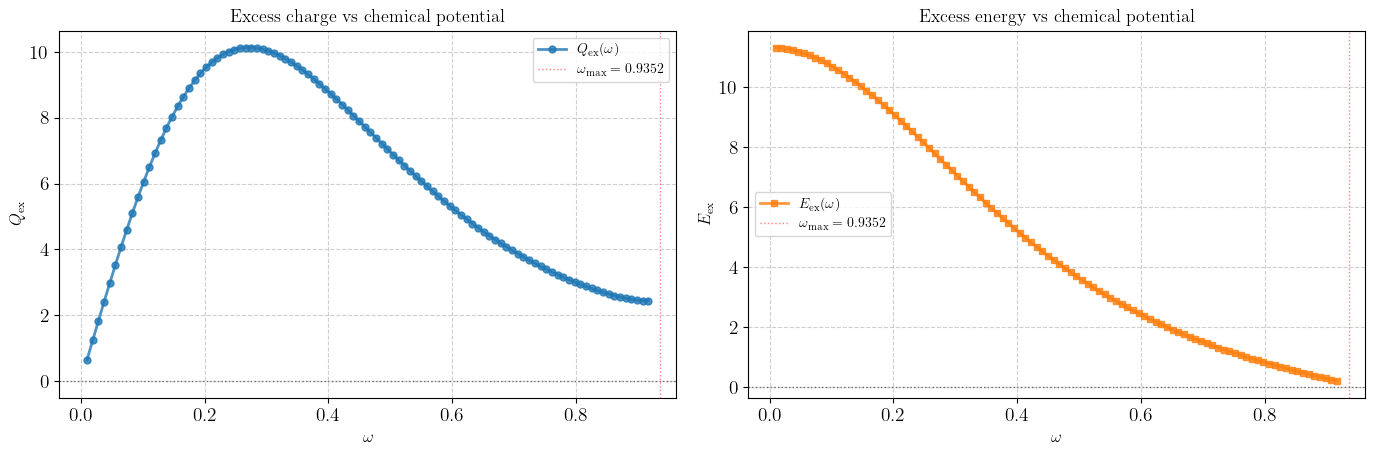

Excess observables (from scan):
  Q_ex range: [0.6486, 10.13]
  E_ex range: [0.1916, 11.32]


In [19]:
# Plot excess charge Q_ex(ω) and excess energy E_ex(ω) (Q_vals, E_vals from scan are already Q_ex, E_ex)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.8))

has_ours = 'omega_valid' in globals() and len(omega_valid) > 0

if has_ours:
    ax1.plot(omega_valid, Q_vals, 'o-', lw=2, markersize=5, color='C0', label=r"$Q_{\mathrm{ex}}(\omega)$", alpha=0.8)
    ax1.set_xlabel(r"$\omega$", fontsize=12)
    ax1.set_ylabel(r"$Q_{\mathrm{ex}}$", fontsize=12)
    ax1.set_title("Excess charge vs chemical potential", fontsize=13)
    ax1.axhline(0, color='k', ls=':', lw=1, alpha=0.5)
    if 'omega_max' in globals():
        ax1.axvline(omega_max, color='r', ls=':', lw=1, alpha=0.5, label=rf"$\omega_{{\max}} = {omega_max:.4f}$")
    ax1.legend(fontsize=10, loc='best')
    ax1.grid(True, ls="--", alpha=0.6)

    ax2.plot(omega_valid, E_vals, 's-', lw=2, markersize=5, color='C1', label=r"$E_{\mathrm{ex}}(\omega)$", alpha=0.8)
    ax2.set_xlabel(r"$\omega$", fontsize=12)
    ax2.set_ylabel(r"$E_{\mathrm{ex}}$", fontsize=12)
    ax2.set_title("Excess energy vs chemical potential", fontsize=13)
    ax2.axhline(0, color='k', ls=':', lw=1, alpha=0.5)
    if 'omega_max' in globals():
        ax2.axvline(omega_max, color='r', ls=':', lw=1, alpha=0.5, label=rf"$\omega_{{\max}} = {omega_max:.4f}$")
    ax2.legend(fontsize=10, loc='best')
    ax2.grid(True, ls="--", alpha=0.6)

    plt.tight_layout()
    plt.show()

    print(f"Excess observables (from scan):")
    print(f"  Q_ex range: [{Q_vals.min():.4g}, {Q_vals.max():.4g}]")
    print(f"  E_ex range: [{E_vals.min():.4g}, {E_vals.max():.4g}]")
else:
    print("No omega scan data found. Run the scan cells first.")

### $E_{\mathrm{ex}} - \omega Q_{\mathrm{ex}}$ vs $Q_{\mathrm{ex}}$

We plot $E_{\mathrm{ex}} - \omega Q_{\mathrm{ex}}$ as a function of the excess charge $Q_{\mathrm{ex}}$ for both methods. This is the Legendre transform of the excess energy with respect to the chemical potential: at fixed $\omega$, $E - \omega Q$ is the relevant free energy. Plotting it vs $Q$ shows how this quantity varies along the scan in $\omega$.

The quantity $E_{\mathrm{ex}} - \omega Q_{\mathrm{ex}}$ includes contributions from the field gradient and the potential energy relative to the false vacuum, minus the $\omega Q$ term.

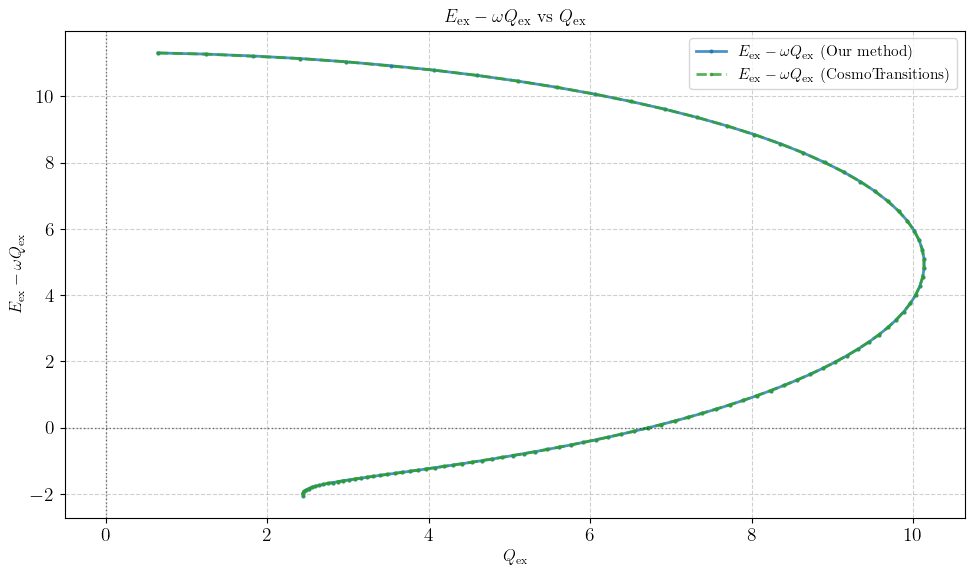


E_ex - ω Q_ex vs Q_ex Statistics

Our method:
  (E_ex - ω Q_ex) range: [-2.050980, 11.308595]
  Mean (E_ex - ω Q_ex): 2.547620
  Std (E_ex - ω Q_ex): 4.413945

CosmoTransitions:
  (E_ex - ω Q_ex) range: [-2.046902, 11.308612]
  Mean (E_ex - ω Q_ex): 2.374106
  Std (E_ex - ω Q_ex): 4.285404

Comparison
  At 97 overlapping Q_ex points:
    Mean |Δ(E_ex - ω Q_ex)| = 6.817829e-02
    Max |Δ(E_ex - ω Q_ex)| = 1.377320e+00
    Mean relative |Δ(E_ex - ω Q_ex)/(E_ex - ω Q_ex)| = 1.40e-01


In [20]:
# Plot E - ω Q vs Q (i.e. E_ex - ω Q_ex vs Q_ex)
fig, ax = plt.subplots(figsize=(10, 6))

# Check if we have both datasets
has_ours = 'omega_valid' in globals() and len(omega_valid) > 0
has_ct = len(omega_valid_ct) > 0

if has_ours or has_ct:
    # E - ω Q (E_vals, Q_vals are E_ex, Q_ex)
    if has_ours:
        E_minus_omega_Q_ours = E_vals - Q_vals * omega_valid
        ax.plot(Q_vals, E_minus_omega_Q_ours, 'o-', lw=2, markersize=2, color='C0', 
                label=r"$E_{\mathrm{ex}} - \omega Q_{\mathrm{ex}}$ (Our method)", alpha=0.8)
    
    if has_ct:
        E_minus_omega_Q_ct = E_vals_ct - Q_vals_ct * omega_valid_ct
        ax.plot(Q_vals_ct, E_minus_omega_Q_ct, 's--', lw=2, markersize=2, color='C2', 
                label=r"$E_{\mathrm{ex}} - \omega Q_{\mathrm{ex}}$ (CosmoTransitions)", alpha=0.8)
    
    ax.set_xlabel(r"$Q_{\mathrm{ex}}$", fontsize=12)
    ax.set_ylabel(r"$E_{\mathrm{ex}} - \omega Q_{\mathrm{ex}}$", fontsize=12)
    ax.set_title(r"$E_{\mathrm{ex}} - \omega Q_{\mathrm{ex}}$ vs $Q_{\mathrm{ex}}$", fontsize=13)
    ax.axhline(0, color='k', ls=':', lw=1, alpha=0.5)
    ax.axvline(0, color='k', ls=':', lw=1, alpha=0.5)
    ax.legend(fontsize=11, loc='best')
    ax.grid(True, ls="--", alpha=0.6)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\n{'='*70}")
    print(f"E_ex - ω Q_ex vs Q_ex Statistics")
    print(f"{'='*70}")
    
    if has_ours:
        print(f"\nOur method:")
        print(f"  (E_ex - ω Q_ex) range: [{E_minus_omega_Q_ours.min():.6f}, {E_minus_omega_Q_ours.max():.6f}]")
        print(f"  Mean (E_ex - ω Q_ex): {E_minus_omega_Q_ours.mean():.6f}")
        print(f"  Std (E_ex - ω Q_ex): {E_minus_omega_Q_ours.std():.6f}")
    
    if has_ct:
        print(f"\nCosmoTransitions:")
        print(f"  (E_ex - ω Q_ex) range: [{E_minus_omega_Q_ct.min():.6f}, {E_minus_omega_Q_ct.max():.6f}]")
        print(f"  Mean (E_ex - ω Q_ex): {E_minus_omega_Q_ct.mean():.6f}")
        print(f"  Std (E_ex - ω Q_ex): {E_minus_omega_Q_ct.std():.6f}")
    
    # Compare if both are available (interpolate E - ω Q as function of Q)
    if has_ours and has_ct:
        print(f"\n{'='*70}")
        print(f"Comparison")
        print(f"{'='*70}")
        
        from scipy.interpolate import interp1d
        
        try:
            # Interpolate our E - ω Q vs Q at CT Q values
            interp_ours = interp1d(Q_vals, E_minus_omega_Q_ours, kind='linear', bounds_error=False, fill_value=np.nan)
            E_minus_omega_Q_ours_at_ct_Q = interp_ours(Q_vals_ct)
            
            valid_mask = ~np.isnan(E_minus_omega_Q_ours_at_ct_Q)
            if np.any(valid_mask):
                diff_diff = E_minus_omega_Q_ct[valid_mask] - E_minus_omega_Q_ours_at_ct_Q[valid_mask]
                print(f"  At {np.sum(valid_mask)} overlapping Q_ex points:")
                print(f"    Mean |Δ(E_ex - ω Q_ex)| = {np.mean(np.abs(diff_diff)):.6e}")
                print(f"    Max |Δ(E_ex - ω Q_ex)| = {np.max(np.abs(diff_diff)):.6e}")
                vals = E_minus_omega_Q_ours_at_ct_Q[valid_mask]
                rel_diff = np.abs(diff_diff) / (np.abs(vals) + 1e-10)
                print(f"    Mean relative |Δ(E_ex - ω Q_ex)/(E_ex - ω Q_ex)| = {np.mean(rel_diff):.2e}")
        except Exception as e:
            print(f"  Could not compute detailed comparison: {str(e)}")
    
    print(f"{'='*70}")
else:
    print("No valid solutions found for plotting. Run the scan cells first.")

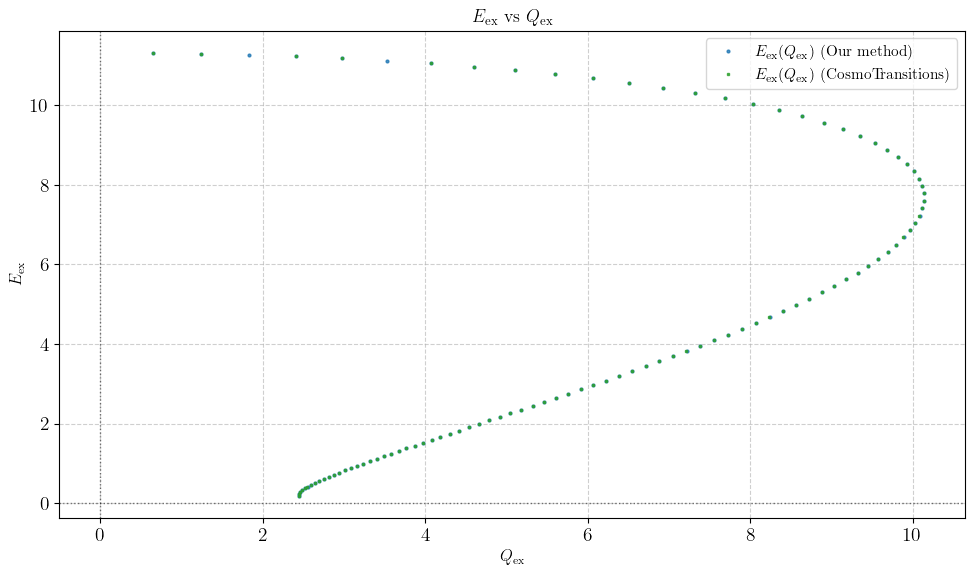


E_ex vs Q_ex Statistics

Our method:
  Q_ex range: [0.648611, 10.1334]
  E_ex range: [0.191635, 11.3151]

CosmoTransitions:
  Q_ex range: [0.648558, 10.132]
  E_ex range: [0.191635, 11.3151]


In [21]:
# Plot E_ex vs Q_ex (Our Method vs CosmoTransitions)
fig, ax = plt.subplots(figsize=(10, 6))

has_ours = 'omega_valid' in globals() and len(omega_valid) > 0
has_ct = 'omega_valid_ct' in globals() and len(omega_valid_ct) > 0

if has_ours or has_ct:
    if has_ours:
        # Sort by Q for a cleaner curve
        idx = np.argsort(Q_vals)
        ax.plot(Q_vals[idx], E_vals[idx], 'o', lw=2, markersize=2, color='C0',
                label=r"$E_{\mathrm{ex}}(Q_{\mathrm{ex}})$ (Our method)", alpha=0.8)

    if has_ct:
        idx = np.argsort(Q_vals_ct)
        ax.plot(Q_vals_ct[idx], E_vals_ct[idx], 's', lw=2, markersize=2, color='C2',
                label=r"$E_{\mathrm{ex}}(Q_{\mathrm{ex}})$ (CosmoTransitions)", alpha=0.8)

    ax.set_xlabel(r"$Q_{\mathrm{ex}}$", fontsize=12)
    ax.set_ylabel(r"$E_{\mathrm{ex}}$", fontsize=12)
    ax.set_title(r"$E_{\mathrm{ex}}$ vs $Q_{\mathrm{ex}}$", fontsize=13)
    ax.axhline(0, color='k', ls=':', lw=1, alpha=0.5)
    ax.axvline(0, color='k', ls=':', lw=1, alpha=0.5)
    ax.legend(fontsize=11, loc='best')
    ax.grid(True, ls="--", alpha=0.6)

    plt.tight_layout()
    plt.show()

    print(f"\n{'='*70}")
    print("E_ex vs Q_ex Statistics")
    print(f"{'='*70}")
    if has_ours:
        print("\nOur method:")
        print(f"  Q_ex range: [{Q_vals.min():.6g}, {Q_vals.max():.6g}]")
        print(f"  E_ex range: [{E_vals.min():.6g}, {E_vals.max():.6g}]")
    if has_ct:
        print("\nCosmoTransitions:")
        print(f"  Q_ex range: [{Q_vals_ct.min():.6g}, {Q_vals_ct.max():.6g}]")
        print(f"  E_ex range: [{E_vals_ct.min():.6g}, {E_vals_ct.max():.6g}]")
    print(f"{'='*70}")
else:
    print("No valid solutions found for plotting. Run the scan cells first.")

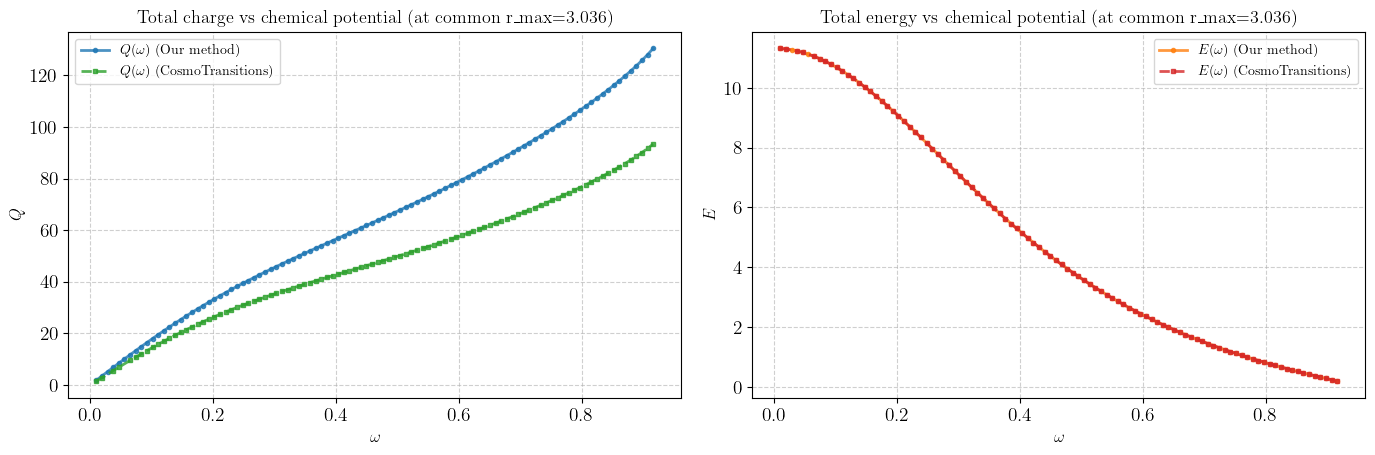

In [22]:
# Plot total Q(ω) and total E(ω) from the scan (volume-corrected at common r_max_min)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.8))

has_ours_tot = 'omega_valid' in globals() and 'Q_tot_vals' in globals() and len(omega_valid) > 0
has_ct_tot = 'omega_valid_ct' in globals() and 'Q_tot_vals_ct' in globals() and len(omega_valid_ct) > 0

if has_ours_tot or has_ct_tot:
    if has_ours_tot:
        ax1.plot(omega_valid, Q_tot_vals, 'o-', lw=2, markersize=3, color='C0', label=r"$Q(\omega)$ (Our method)", alpha=0.8)
        ax2.plot(omega_valid, E_tot_vals, 'o-', lw=2, markersize=3, color='C1', label=r"$E(\omega)$ (Our method)", alpha=0.8)

    if has_ct_tot:
        ax1.plot(omega_valid_ct, Q_tot_vals_ct, 's--', lw=2, markersize=3, color='C2', label=r"$Q(\omega)$ (CosmoTransitions)", alpha=0.8)
        ax2.plot(omega_valid_ct, E_tot_vals_ct, 's--', lw=2, markersize=3, color='C3', label=r"$E(\omega)$ (CosmoTransitions)", alpha=0.8)

    # Titles indicate volume correction (Q and E at common r_max_min from scan cells)
    r_max_note_ours = f" (at common r_max={r_max_min:.3f})" if has_ours_tot and 'r_max_min' in globals() else ""
    r_max_note_ct = f" (at common r_max={r_max_min_ct:.3f})" if has_ct_tot and 'r_max_min_ct' in globals() else ""
    r_max_note = r_max_note_ours or r_max_note_ct or " (volume-corrected at common r_max)"
    ax1.set_xlabel(r"$\omega$", fontsize=12)
    ax1.set_ylabel(r"$Q$", fontsize=12)
    ax1.set_title("Total charge vs chemical potential" + r_max_note, fontsize=13)
    ax1.grid(True, ls="--", alpha=0.6)
    ax1.legend(fontsize=10, loc='best')

    ax2.set_xlabel(r"$\omega$", fontsize=12)
    ax2.set_ylabel(r"$E$", fontsize=12)
    ax2.set_title("Total energy vs chemical potential" + r_max_note, fontsize=13)
    ax2.grid(True, ls="--", alpha=0.6)
    ax2.legend(fontsize=10, loc='best')

    plt.tight_layout()
    plt.show()
else:
    print("No total Q/E scan data found. Run the scan cells first.")

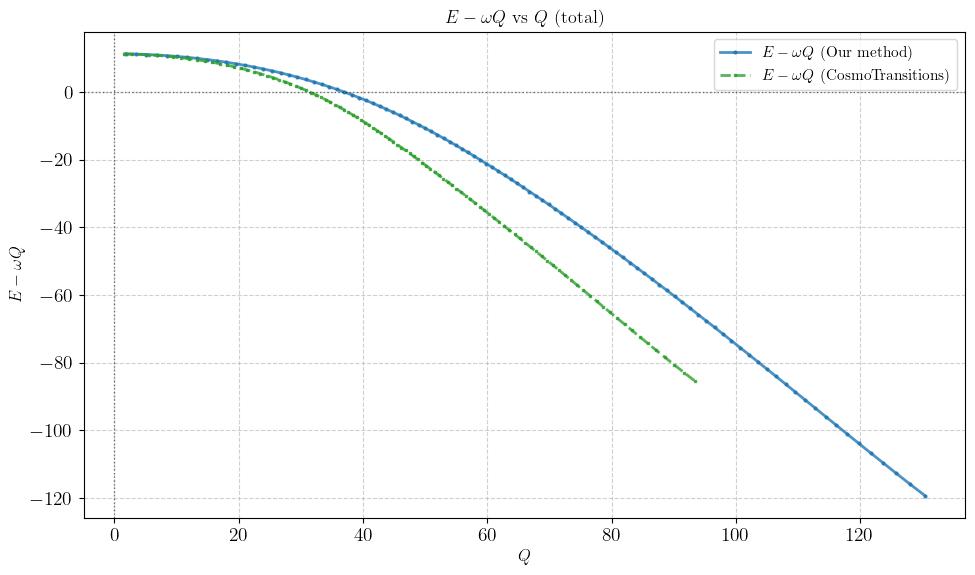

In [23]:
# Plot (E - ω Q) vs Q using total E,Q from the scan (no background subtraction)
fig, ax = plt.subplots(figsize=(10, 6))

has_ours_tot = 'omega_valid' in globals() and 'Q_tot_vals' in globals() and len(omega_valid) > 0
has_ct_tot = 'omega_valid_ct' in globals() and 'Q_tot_vals_ct' in globals() and len(omega_valid_ct) > 0

if has_ours_tot or has_ct_tot:
    if has_ours_tot:
        F_ours = E_tot_vals - omega_valid * Q_tot_vals
        idx = np.argsort(Q_tot_vals)
        ax.plot(Q_tot_vals[idx], F_ours[idx], 'o-', lw=2, markersize=2, color='C0',
                label=r"$E-\omega Q$ (Our method)", alpha=0.8)

    if has_ct_tot:
        F_ct = E_tot_vals_ct - omega_valid_ct * Q_tot_vals_ct
        idx = np.argsort(Q_tot_vals_ct)
        ax.plot(Q_tot_vals_ct[idx], F_ct[idx], 's--', lw=2, markersize=2, color='C2',
                label=r"$E-\omega Q$ (CosmoTransitions)", alpha=0.8)

    ax.set_xlabel(r"$Q$", fontsize=12)
    ax.set_ylabel(r"$E-\omega Q$", fontsize=12)
    ax.set_title(r"$E-\omega Q$ vs $Q$ (total)", fontsize=13)
    ax.axhline(0, color='k', ls=':', lw=1, alpha=0.5)
    ax.axvline(0, color='k', ls=':', lw=1, alpha=0.5)
    ax.legend(fontsize=11, loc='best')
    ax.grid(True, ls="--", alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("No total Q/E scan data found. Run the scan cells first.")

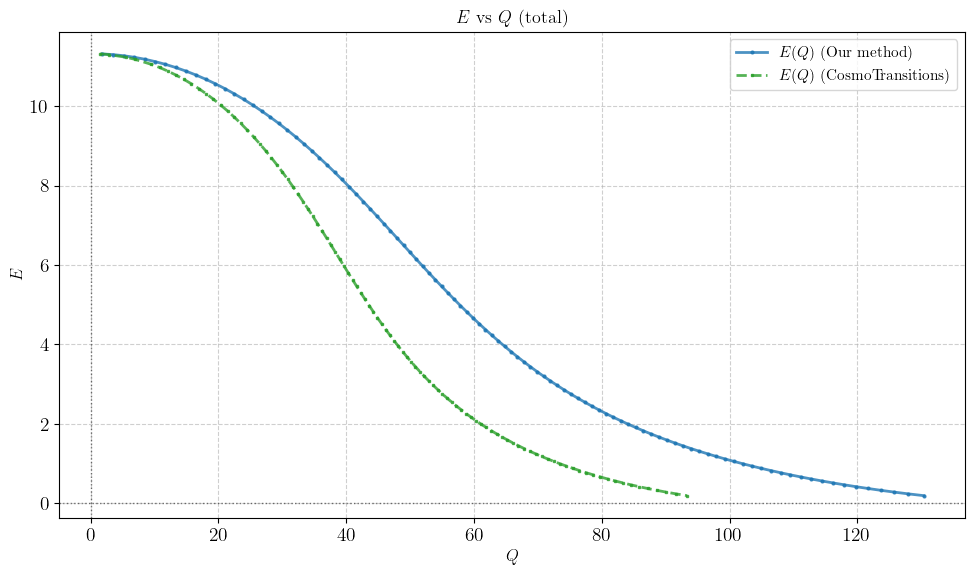

In [24]:
# Plot total E vs total Q (no background subtraction)
fig, ax = plt.subplots(figsize=(10, 6))

has_ours_tot = 'omega_valid' in globals() and 'Q_tot_vals' in globals() and len(omega_valid) > 0
has_ct_tot = 'omega_valid_ct' in globals() and 'Q_tot_vals_ct' in globals() and len(omega_valid_ct) > 0

if has_ours_tot or has_ct_tot:
    if has_ours_tot:
        idx = np.argsort(Q_tot_vals)
        ax.plot(Q_tot_vals[idx], E_tot_vals[idx], 'o-', lw=2, markersize=2, color='C0',
                label=r"$E(Q)$ (Our method)", alpha=0.8)

    if has_ct_tot:
        idx = np.argsort(Q_tot_vals_ct)
        ax.plot(Q_tot_vals_ct[idx], E_tot_vals_ct[idx], 's--', lw=2, markersize=2, color='C2',
                label=r"$E(Q)$ (CosmoTransitions)", alpha=0.8)

    ax.set_xlabel(r"$Q$", fontsize=12)
    ax.set_ylabel(r"$E$", fontsize=12)
    ax.set_title(r"$E$ vs $Q$ (total)", fontsize=13)
    ax.axhline(0, color='k', ls=':', lw=1, alpha=0.5)
    ax.axvline(0, color='k', ls=':', lw=1, alpha=0.5)
    ax.legend(fontsize=11, loc='best')
    ax.grid(True, ls="--", alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("No total Q/E scan data found. Run the scan cells first.")

## Homogeneous configuration: energy and charge

For the **homogeneous** (false vacuum) configuration, the field is constant in space: $\phi(r) = \phi_{\mathrm{false}}(\omega)$, with $\phi_{\mathrm{false}}$ the metastable minimum of the grand potential $\Omega(\phi)$ at each $\omega$.

- **Charge:** $Q_{\mathrm{hom}} = V \cdot \omega \, \phi_{\mathrm{false}}^2$, with $V = \frac{4}{3}\pi r_{\max}^3$ the reference volume.
- **Energy:** $E_{\mathrm{hom}} = V \cdot \left[ \frac{1}{2}\omega^2 \phi_{\mathrm{false}}^2 + V(\phi_{\mathrm{false}}) \right]$.

We compute $Q_{\mathrm{hom}}(\omega)$ and $E_{\mathrm{hom}}(\omega)$ for the same $\omega$ values as the bubble scan, using the same volume reference (e.g. $r_{\max}$ from the scan) so that bubble and homogeneous curves are comparable.

In [25]:
# ============================================================================
# Homogeneous configuration: Q_hom(omega) and E_hom(omega)
# ============================================================================
# Use same volume reference as in the scan (SCAN_RMAX if available)
r_max_ref = ((4.0 / 3.0) * np.pi)**(-1/3)
V_ref = (4.0 / 3.0) * np.pi * r_max_ref**3

phi0_scan = PHI0_BOUNCE if 'PHI0_BOUNCE' in globals() else PHI0
v1_scan = V1_BOUNCE if 'V1_BOUNCE' in globals() else V1
v2_scan = V2_BOUNCE if 'V2_BOUNCE' in globals() else V2

Q_hom_vals = np.array([])
E_hom_vals = np.array([])
omega_hom = np.array([])

if 'omega_valid' in globals() and len(omega_valid) > 0:
    Q_hom_list = []
    E_hom_list = []
    for om in omega_valid:
        phi_false_om, _ = vacua_of_Omega(phi0_scan, v1_scan, v2_scan, om)
        # Q_hom = V * omega * phi_false^2
        Q_hom_list.append(V_ref * om * phi_false_om**2)
        # E_hom = V * [ (1/2) omega^2 phi_false^2 + V(phi_false) ]
        V_phi_false = V_phi(phi_false_om, phi0_scan, v1_scan, v2_scan)
        E_hom_list.append(V_ref * (0.5 * om**2 * phi_false_om**2 + V_phi_false-V_phi_false))
    Q_hom_vals = np.array(Q_hom_list)
    E_hom_vals = np.array(E_hom_list)
    omega_hom = np.asarray(omega_valid)
    print(f"Homogeneous: computed for {len(omega_hom)} omega values (V_ref = (4/3)π {r_max_ref:.1f}^3)")

if len(omega_hom) > 0:
    print(f"  Q_hom range: [{Q_hom_vals.min():.4f}, {Q_hom_vals.max():.4f}]")
    print(f"  E_hom range: [{E_hom_vals.min():.4f}, {E_hom_vals.max():.4f}]")

Homogeneous: computed for 100 omega values (V_ref = (4/3)π 0.6^3)
  Q_hom range: [0.0100, 1.0916]
  E_hom range: [0.0001, 0.5002]


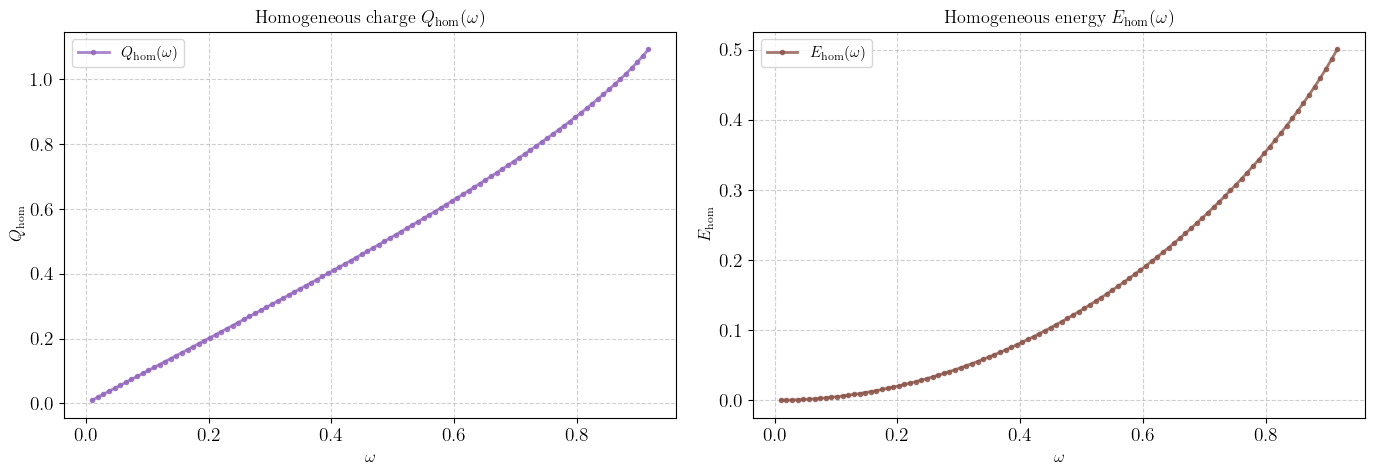

In [26]:
# Plot Q_hom(omega) and E_hom(omega)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

if len(omega_hom) > 0:
    ax1.plot(omega_hom, Q_hom_vals, 'o-', lw=2, markersize=3, color='C4', label=r"$Q_{\mathrm{hom}}(\omega)$", alpha=0.8)
    ax2.plot(omega_hom, E_hom_vals, 'o-', lw=2, markersize=3, color='C5', label=r"$E_{\mathrm{hom}}(\omega)$", alpha=0.8)

ax1.set_xlabel(r"$\omega$", fontsize=12)
ax1.set_ylabel(r"$Q_{\mathrm{hom}}$", fontsize=12)
ax1.set_title(r"Homogeneous charge $Q_{\mathrm{hom}}(\omega)$", fontsize=13)
ax1.legend(fontsize=11)
ax1.grid(True, ls="--", alpha=0.6)

ax2.set_xlabel(r"$\omega$", fontsize=12)
ax2.set_ylabel(r"$E_{\mathrm{hom}}$", fontsize=12)
ax2.set_title(r"Homogeneous energy $E_{\mathrm{hom}}(\omega)$", fontsize=13)
ax2.legend(fontsize=11)
ax2.grid(True, ls="--", alpha=0.6)
plt.tight_layout()
plt.show()

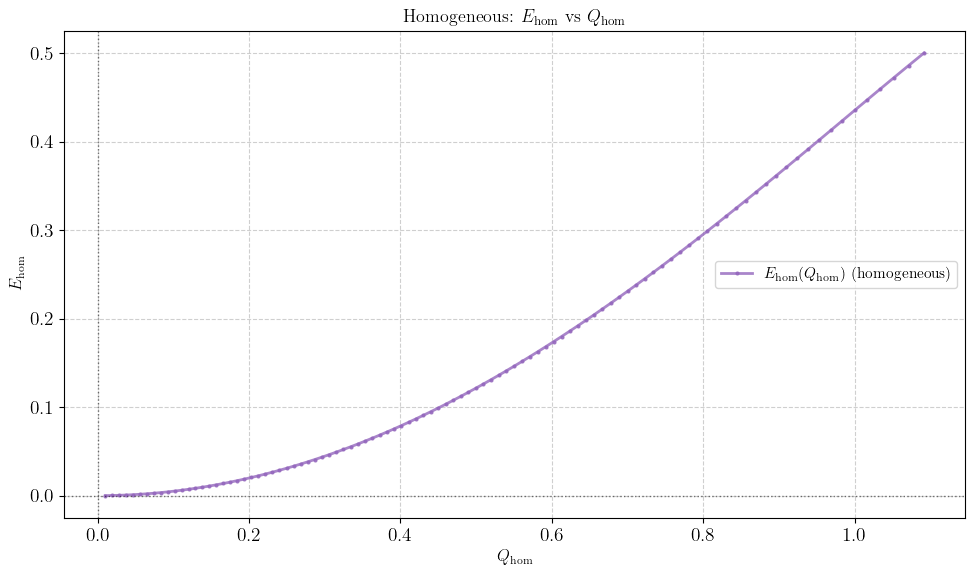

In [27]:
# Plot E_hom vs Q_hom (homogeneous)
fig, ax = plt.subplots(figsize=(10, 6))
if len(omega_hom) > 0:
    idx = np.argsort(Q_hom_vals)
    ax.plot(Q_hom_vals[idx], E_hom_vals[idx], 'o-', lw=2, markersize=2, color='C4',
            label=r"$E_{\mathrm{hom}}(Q_{\mathrm{hom}})$ (homogeneous)", alpha=0.8)
ax.set_xlabel(r"$Q_{\mathrm{hom}}$", fontsize=12)
ax.set_ylabel(r"$E_{\mathrm{hom}}$", fontsize=12)
ax.set_title(r"Homogeneous: $E_{\mathrm{hom}}$ vs $Q_{\mathrm{hom}}$", fontsize=13)
ax.axhline(0, color='k', ls=':', lw=1, alpha=0.5)
ax.axvline(0, color='k', ls=':', lw=1, alpha=0.5)
ax.legend(fontsize=11)
ax.grid(True, ls="--", alpha=0.6)
plt.tight_layout()
plt.show()

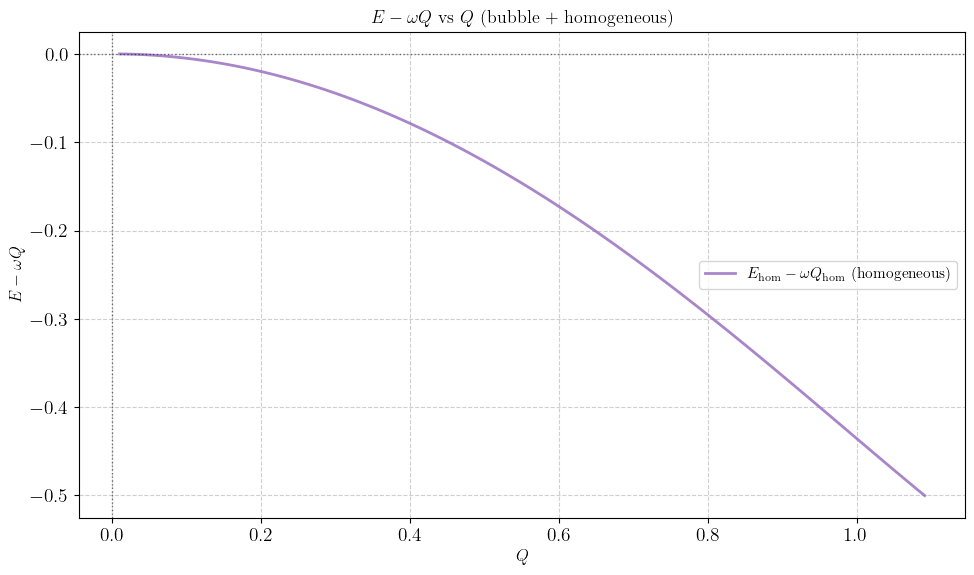

In [28]:
# E - omega Q vs Q (bubble + homogeneous on same axes)
fig, ax = plt.subplots(figsize=(10, 6))

has_ours = 'omega_valid' in globals() and 'Q_tot_vals' in globals() and len(omega_valid) > 0
has_ct = 'omega_valid_ct' in globals() and 'Q_tot_vals_ct' in globals() and len(omega_valid_ct) > 0
has_hom = 'omega_hom' in globals() and len(omega_hom) > 0

if has_hom:
    F_hom = E_hom_vals - omega_hom * Q_hom_vals
    idx = np.argsort(Q_hom_vals)
    ax.plot(Q_hom_vals[idx], F_hom[idx], '-', lw=2, color='C4', label=r"$E_{\mathrm{hom}}-\omega Q_{\mathrm{hom}}$ (homogeneous)", alpha=0.8)

ax.set_xlabel(r"$Q$", fontsize=12)
ax.set_ylabel(r"$E - \omega Q$", fontsize=12)
ax.set_title(r"$E - \omega Q$ vs $Q$ (bubble + homogeneous)", fontsize=13)
ax.axhline(0, color='k', ls=':', lw=1, alpha=0.5)
ax.axvline(0, color='k', ls=':', lw=1, alpha=0.5)
#ax.set_xlim(Q_hom_vals.min(), 0.02)
#ax.set_ylim(-0.01, 0.01)
ax.legend(fontsize=11, loc='best')
ax.grid(True, ls="--", alpha=0.6)
plt.tight_layout()
plt.show()

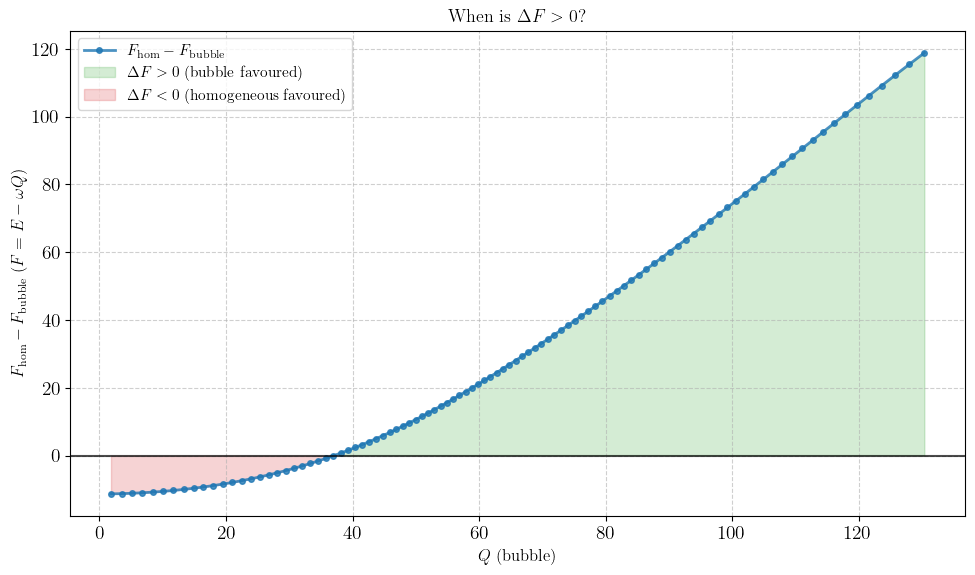

In [29]:
# F_hom - F_bubble vs Q, with F = E - omega*Q (when positive, homogeneous is favoured)
from scipy.interpolate import interp1d

fig, ax = plt.subplots(figsize=(10, 6))

has_ours = 'omega_valid' in globals() and 'Q_tot_vals' in globals() and len(omega_valid) > 0
has_hom = 'omega_hom' in globals() and len(omega_hom) > 0

if has_ours and has_hom:
    F_bubble = E_tot_vals - omega_valid * Q_tot_vals
    F_hom_vals = E_hom_vals - omega_hom * Q_hom_vals
    # Interpolate F_hom to bubble omega grid
    F_hom_interp = interp1d(omega_hom, F_hom_vals, kind='linear', bounds_error=False, fill_value=np.nan)
    F_hom_at_bubble_omega = F_hom_interp(omega_valid)
    Delta_F = F_hom_at_bubble_omega - F_bubble
    # Plot Delta_F vs Q (bubble Q at each omega)
    idx = np.argsort(Q_tot_vals)
    ax.plot(Q_tot_vals[idx], Delta_F[idx], 'o-', lw=2, markersize=4, color='C0', label=r"$F_{\mathrm{hom}} - F_{\mathrm{bubble}}$", alpha=0.8)
    ax.axhline(0, color='k', ls='-', lw=1.5, alpha=0.7)
    ax.fill_between(Q_tot_vals[idx], 0, Delta_F[idx], where=(Delta_F[idx] >= 0), alpha=0.2, color='C2', label=r"$\Delta F > 0$ (bubble favoured)")
    ax.fill_between(Q_tot_vals[idx], 0, Delta_F[idx], where=(Delta_F[idx] < 0), alpha=0.2, color='C3', label=r"$\Delta F < 0$ (homogeneous favoured)")
else:
    ax.text(0.5, 0.5, "Run omega scan and homogeneous cells first.", ha='center', va='center', transform=ax.transAxes)

ax.set_xlabel(r"$Q$ (bubble)", fontsize=12)
ax.set_ylabel(r"$F_{\mathrm{hom}} - F_{\mathrm{bubble}}$  ($F = E - \omega Q$)", fontsize=12)
ax.set_title(r"When is $\Delta F > 0$?", fontsize=13)
ax.legend(fontsize=11, loc='best')
ax.grid(True, ls="--", alpha=0.6)
plt.tight_layout()
plt.show()

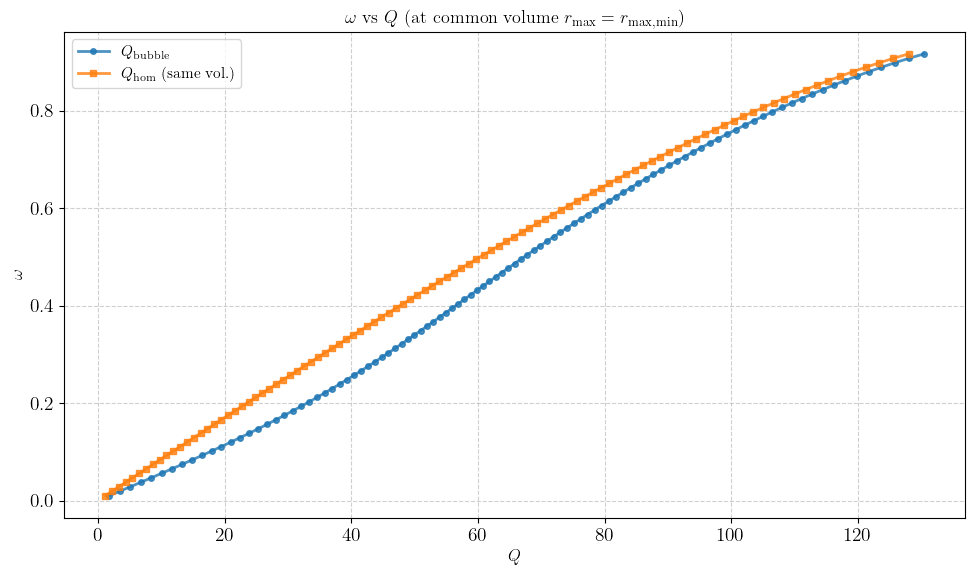

In [30]:
# Q_hom and Q_bubble vs omega (same volume: V_min = (4/3)π r_max_min³)
fig, ax = plt.subplots(figsize=(10, 6))
has_ours = 'omega_valid' in globals() and 'Q_tot_vals' in globals() and len(omega_valid) > 0
has_vol = has_ours and 'r_max_min' in globals() and 'phi_false_vals' in globals()
if has_vol:
    V_min = (4.0 / 3.0) * np.pi * r_max_min**3
    # Q_bubble already volume-corrected at r_max_min
    Q_bubble = Q_tot_vals
    # Q_hom at same volume: Q_hom = V_min * omega * phi_false^2
    Q_hom_same_vol = V_min * omega_valid * phi_false_vals**2
    # omega in funzione di Q: asse x = Q, asse y = omega
    ax.plot(Q_bubble, omega_valid, 'o-', lw=2, markersize=4, color='C0', label=r'$Q_{\mathrm{bubble}}$', alpha=0.8)
    ax.plot(Q_hom_same_vol, omega_valid, 's-', lw=2, markersize=4, color='C1', label=r'$Q_{\mathrm{hom}}$ (same vol.)', alpha=0.8)
else:
    ax.text(0.5, 0.5, "Run omega scan first.", ha='center', va='center', transform=ax.transAxes)
ax.set_xlabel(r"$Q$", fontsize=12)
ax.set_ylabel(r"$\omega$", fontsize=12)
ax.set_title(r"$\omega$ vs $Q$ (at common volume $r_{\max}=r_{\max,\min}$)", fontsize=13)
ax.legend(fontsize=11, loc='best')
ax.grid(True, ls="--", alpha=0.6)
plt.tight_layout()
plt.show()

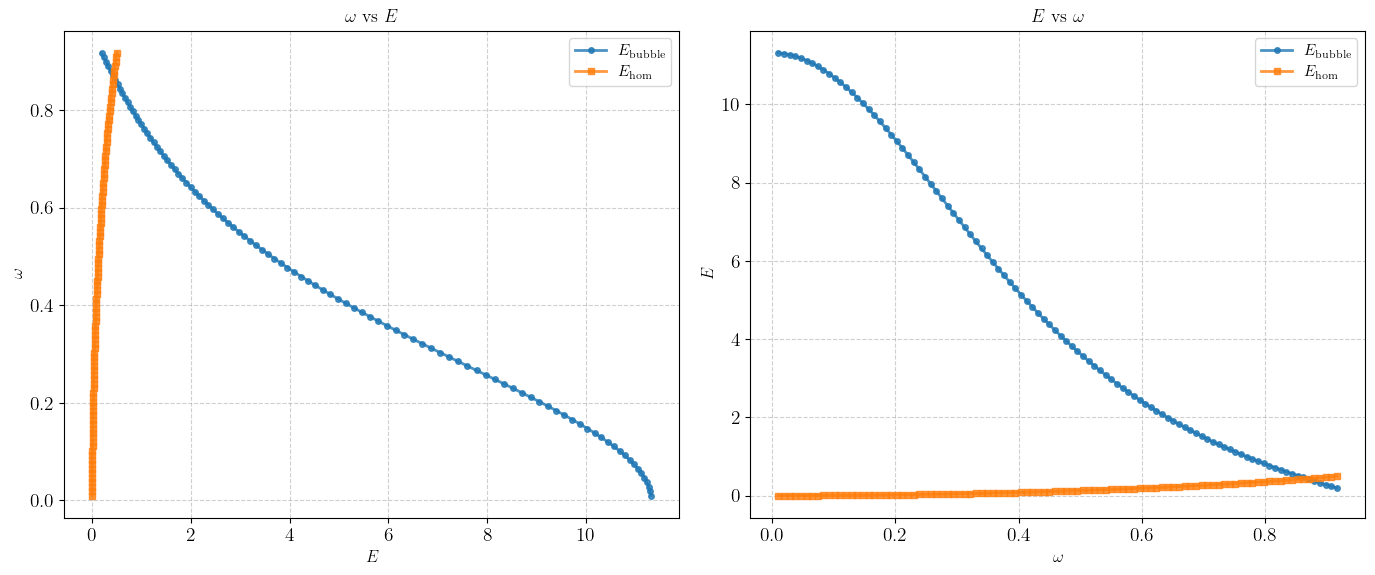

In [ ]:
# Energia bolla e omogenea: omega vs E e E vs omega
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
has_ours = 'omega_valid' in globals() and 'E_tot_vals' in globals() and len(omega_valid) > 0
has_hom = 'omega_hom' in globals() and 'E_hom_vals' in globals() and len(omega_hom) > 0
if has_ours and has_hom:
    # Sinistra: omega in funzione di E (x=E, y=omega)
    ax1.plot(E_tot_vals, omega_valid, 'o-', lw=2, markersize=4, color='C0', label=r'$E_{\mathrm{bubble}}$', alpha=0.8)
    ax1.plot(E_hom_vals, omega_hom, 's-', lw=2, markersize=4, color='C1', label=r'$E_{\mathrm{hom}}$', alpha=0.8)
    ax1.set_xlabel(r"$E$", fontsize=12)
    ax1.set_ylabel(r"$\omega$", fontsize=12)
    ax1.set_title(r"$\omega$ vs $E$", fontsize=13)
    ax1.legend(fontsize=11, loc='best')
    ax1.grid(True, ls="--", alpha=0.6)
    # Destra: E in funzione di omega (x=omega, y=E)
    ax2.plot(omega_valid, E_tot_vals, 'o-', lw=2, markersize=4, color='C0', label=r'$E_{\mathrm{bubble}}$', alpha=0.8)
    ax2.plot(omega_hom, E_hom_vals, 's-', lw=2, markersize=4, color='C1', label=r'$E_{\mathrm{hom}}$', alpha=0.8)
    ax2.set_xlabel(r"$\omega$", fontsize=12)
    ax2.set_ylabel(r"$E$", fontsize=12)
    ax2.set_title(r"$E$ vs $\omega$", fontsize=13)
    ax2.legend(fontsize=11, loc='best')
    ax2.grid(True, ls="--", alpha=0.6)
else:
    for ax in (ax1, ax2):
        ax.text(0.5, 0.5, "Run omega scan and homogeneous cells first.", ha='center', va='center', transform=ax.transAxes)
plt.tight_layout()
plt.show()

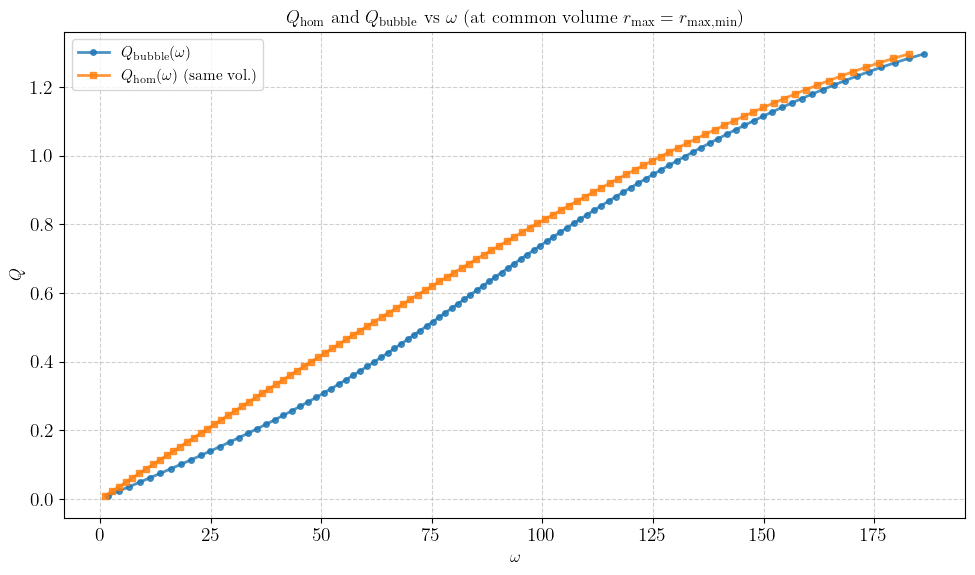

In [97]:
# Q_hom and Q_bubble vs omega (same volume: V_min = (4/3)π r_max_min³)
fig, ax = plt.subplots(figsize=(10, 6))
has_ours = 'omega_valid' in globals() and 'Q_tot_vals' in globals() and len(omega_valid) > 0
has_vol = has_ours and 'r_max_min' in globals() and 'phi_false_vals' in globals()
if has_vol:
    V_min = (4.0 / 3.0) * np.pi * r_max_min**3
    # Q_bubble already volume-corrected at r_max_min
    Q_bubble = Q_tot_vals
    # Q_hom at same volume: Q_hom = V_min * omega * phi_false^2
    Q_hom_same_vol = V_min * omega_valid * phi_false_vals**2
    ax.plot(Q_bubble,omega_valid, 'o-', lw=2, markersize=4, color='C0', label=r'$Q_{\mathrm{bubble}}(\omega)$', alpha=0.8)
    ax.plot(Q_hom_same_vol,omega_valid, 's-', lw=2, markersize=4, color='C1', label=r'$Q_{\mathrm{hom}}(\omega)$ (same vol.)', alpha=0.8)
else:
    ax.text(0.5, 0.5, "Run omega scan first.", ha='center', va='center', transform=ax.transAxes)
ax.set_xlabel(r"$\omega$", fontsize=12)
ax.set_ylabel(r"$Q$", fontsize=12)
ax.set_title(r"$Q_{\mathrm{hom}}$ and $Q_{\mathrm{bubble}}$ vs $\omega$ (at common volume $r_{\max}=r_{\max,\min}$)", fontsize=13)
ax.legend(fontsize=11, loc='best')
ax.grid(True, ls="--", alpha=0.6)
plt.tight_layout()
plt.show()

## Negative Mode Around Critical Bubble

To construct a good initial ansatz for the 2D bounce solution, we compute the unstable eigenmode around the critical bubble profile. This mode describes the direction of fastest growth away from the critical bubble configuration.

The fluctuation operator in the l=0 (spherically symmetric) channel is:

$$[-d^2/dr^2 + V''(\phi_{cb}(r))] u = \lambda u$$

with Dirichlet boundary conditions $u(0) = 0$ and $u(r_{\max}) = 0$. The negative eigenvalue $\lambda_- < 0$ gives the growth rate $\gamma = \sqrt{-\lambda_-}$, which determines the natural Euclidean time scale $\beta \approx 2\pi/\gamma$ for the bounce solution.

The mode function $\xi(r) = u(r)/r$ is normalized with the L2 norm on $r^2 dr$.

Computing negative mode around critical bubble...

Negative mode computed:
  Growth rate γ              = 1.150496
  Negative eigenvalue λ      = -1.323641
  Natural β = 2π/γ            = 5.461284
  Mode normalization: ∫ r² ξ² dr = 1


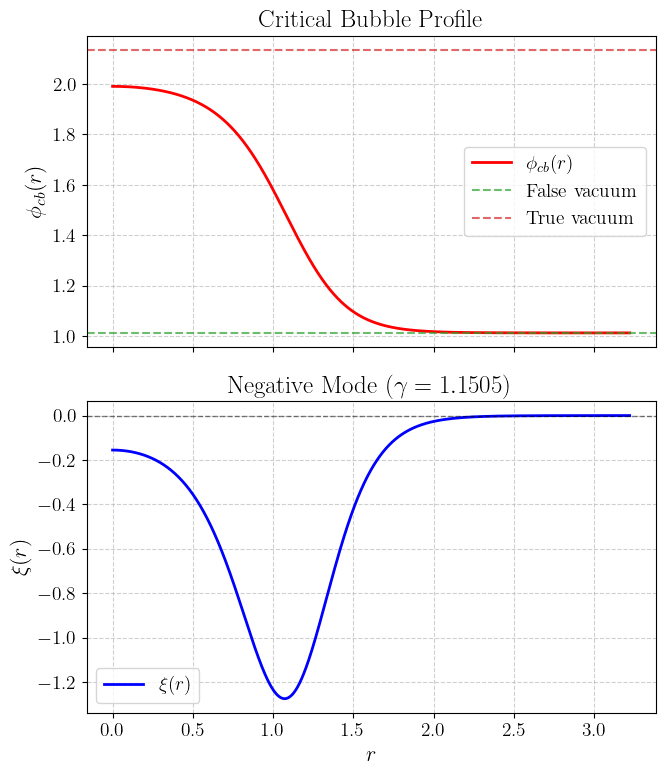

In [24]:
# ============================================================================
# Compute Negative Mode Around Critical Bubble
# ============================================================================

from Bubble_finder.ansatz_bubble import compute_negative_mode, UnstableMode

OMEGA_BOUNCE = 0.2

# Use the bounce solution from cell 7 (if available)
if 'r_bounce' in globals() and r_bounce is not None:
    # Extract critical bubble profile
    profile_cb = phi_bounce  # phi_cb(r) from the bounce solution
    grid_r = r_bounce
    
    # Define V''(phi) for the grand potential
    # V''(phi) = d²V/dφ² - 2ω² (since Ω = V - ω²φ²)
    def Vpp(phi):
        """Second derivative of grand potential: d²Ω/dφ² = d²V/dφ² - 2ω²"""
        d2V = d2V_dphi2(phi, PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE)
        return d2V - OMEGA_BOUNCE**2
    
    # Compute negative mode
    print("Computing negative mode around critical bubble...")
    # Restrict gamma scan to include sign change around 1.25
    # The shooting function D_p(gamma) changes sign near gamma ≈ 1.25
    unstable_mode = compute_negative_mode(
        profile_cb, grid_r, Vpp,
        compute_shooting=True,
        gamma_scan=(0.5, 1.5),  # Focus around sign change at ~1.25
        n_scan=100
    )
    
    # Compute natural beta from growth rate
    beta_natural = 2.0 * np.pi / unstable_mode.gamma
    
    print(f"\nNegative mode computed:")
    print(f"  Growth rate γ              = {unstable_mode.gamma:.6f}")
    print(f"  Negative eigenvalue λ      = {unstable_mode.lambda_neg:.6f}")
    print(f"  Natural β = 2π/γ            = {beta_natural:.6f}")
    print(f"  Mode normalization: ∫ r² ξ² dr = 1")
    
    # Plot mode together with bubble profile
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 8), sharex=True)
    
    # Top: bubble profile
    ax1.plot(r_bounce, phi_bounce, 'r-', lw=2, label=r"$\phi_{cb}(r)$")
    ax1.axhline(phi_false_bounce, color='C2', ls='--', lw=1.5, label="False vacuum", alpha=0.7)
    ax1.axhline(phi_true_bounce if 'phi_true_bounce' in globals() else phi_bounce[0], 
                color='C3', ls='--', lw=1.5, label="True vacuum", alpha=0.7)
    ax1.set_ylabel(r"$\phi_{cb}(r)$")
    ax1.set_title("Critical Bubble Profile")
    ax1.legend()
    ax1.grid(True, ls="--", alpha=0.6)
    
    # Bottom: negative mode
    ax2.plot(unstable_mode.r, unstable_mode.xi, 'b-', lw=2, label=r"$\xi(r)$")
    ax2.axhline(0, color='k', ls='--', lw=1, alpha=0.5)
    ax2.set_xlabel(r"$r$")
    ax2.set_ylabel(r"$\xi(r)$")
    ax2.set_title(rf"Negative Mode ($\gamma = {unstable_mode.gamma:.4f}$)")
    ax2.legend()
    ax2.grid(True, ls="--", alpha=0.6)
    
    plt.tight_layout()
    plt.show()
    
else:
    print("Error: No bounce solution available. Please run the bounce solver cell (cell 7) first.")
    unstable_mode = None
    beta_natural = None

## Shooting Function Verification

The shooting function $D_p(\gamma)$ is computed during the eigenvalue search to verify that the found value of $\gamma$ is correct. It measures the mismatch in boundary conditions for the linearized mode equation. The eigenvalue $\gamma$ is found where $D_p(\gamma) = 0$.

The plot shows $\log_{10}|D_p(\gamma)|$ as a function of $\gamma$. The zero crossing (sign change) identifies the interval containing the eigenvalue, which should match the value found by the direct eigenvalue method.

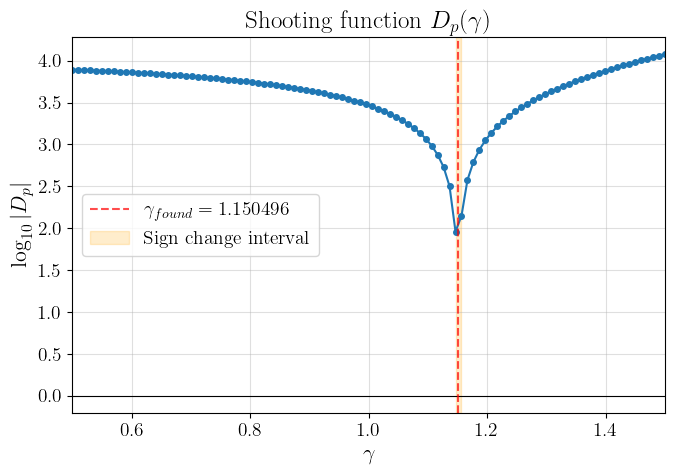


Shooting function verification:
  Found γ = 1.150496
  Sign change bracket: [1.146465, 1.156566]
  γ is within bracket: True
  D_p(γ_found) ≈ 1.589819e+00
  |D_p(γ_found)| < 1e-3: False


In [25]:
# Plot shooting function D_p(gamma) using values from compute_negative_mode
# The unstable_mode object now contains gamma_grid and Dp_vals

if unstable_mode is not None:
    # Extract gamma_grid and Dp_vals from unstable_mode (already computed in previous cell)
    gamma_grid = unstable_mode.gamma_grid
    Dp_vals = unstable_mode.Dp_vals
    
    if gamma_grid is not None and Dp_vals is not None:
        # Find bracket for sign change (if not already found)
        bracket = None
        for i in range(len(gamma_grid) - 1):
            if np.sign(Dp_vals[i]) != np.sign(Dp_vals[i + 1]):
                bracket = (gamma_grid[i], gamma_grid[i + 1])
                break
        
        plt.figure(figsize=(7, 5))
        plt.plot(gamma_grid, np.log10(np.abs(Dp_vals) + 1e-300), '-o', lw=1.5, ms=4)
        plt.axhline(0, color='k', lw=0.8)
        plt.axvline(unstable_mode.gamma, color='r', ls='--', lw=1.5, 
                   label=rf"$\gamma_{{found}} = {unstable_mode.gamma:.6f}$", alpha=0.7)
        plt.xlabel(r'$\gamma$')
        plt.ylabel(r'$\log_{10}|D_p|$')
        plt.title(r'Shooting function $D_p(\gamma)$')
        plt.xlim(min(gamma_grid), max(gamma_grid))  # Limit x-axis to max gamma
        plt.grid(True, alpha=0.4)
        
        # Optional: mark bracket region if found
        if bracket is not None:
            plt.axvspan(bracket[0], bracket[1], color='orange', alpha=0.2, label='Sign change interval')
            plt.legend()
        else:
            plt.legend()
        
        plt.tight_layout()
        plt.show()
        
        # Print verification
        print(f"\nShooting function verification:")
        print(f"  Found γ = {unstable_mode.gamma:.6f}")
        if bracket is not None:
            print(f"  Sign change bracket: [{bracket[0]:.6f}, {bracket[1]:.6f}]")
            print(f"  γ is within bracket: {bracket[0] <= unstable_mode.gamma <= bracket[1]}")
        
        # Find the value of D_p at the found gamma
        if len(gamma_grid) > 0:
            # Interpolate to find D_p at the found gamma
            from scipy.interpolate import interp1d
            Dp_interp = interp1d(gamma_grid, Dp_vals, kind='linear', bounds_error=False, fill_value=np.nan)
            Dp_at_gamma = Dp_interp(unstable_mode.gamma)
            print(f"  D_p(γ_found) ≈ {Dp_at_gamma:.6e}")
            print(f"  |D_p(γ_found)| < 1e-3: {abs(Dp_at_gamma) < 1e-3}")
    else:
        print("Shooting function not computed. Set compute_shooting=True in compute_negative_mode.")
else:
    print("Error: Negative mode not computed. Please run the previous cell first.")

## 2D Ansatz Construction

We now construct the two-dimensional initial ansatz for the full bounce solution. Two approaches are available:

**(A) Clean Negative-Mode Ansatz:**
$$\phi(r, \tau) = \phi_{cb}(r) + A \cdot \xi(r) \cdot \cos(\gamma(\tau - \tau_0))$$

This ansatz is centered around the critical bubble profile $\phi_{cb}(r)$ with a time-dependent perturbation along the negative mode direction. With $\tau_0=0$ (default), it satisfies $\partial\phi/\partial\tau|_{\tau=0} = 0$ (Neumann condition at $\tau=0$), but does not automatically enforce the correct endpoint values. The amplitude $A$ and optional Gaussian envelope can be tuned to optimize convergence.

**Note:** The clean ansatz is mathematically motivated by the negative mode structure, but may require tuning to satisfy boundary conditions at $\tau = -\beta/2$.

**(B) Anchored Ansatz:**
$$\phi(r, \tau) = \phi_{\text{hom}} + s(\tau) \cdot (\phi_{cb}(r) - \phi_{\text{hom}}) + \epsilon \cdot s(\tau)(1-s(\tau)) \cdot \xi(r) \cdot \text{envelope}(\tau)$$

where $s(\tau) = \sin^2(\pi(\tau + \beta/2)/\beta)$ is a smooth interpolation function that ensures exact endpoint slices by construction:
- $\phi(r, -\beta/2) = \phi_{\text{hom}}$ (homogeneous false vacuum)
- $\phi(r, 0) = \phi_{cb}(r)$ (critical bubble)

The second term adds a small negative-mode kick (amplitude $\epsilon$) that vanishes at the endpoints due to the $s(1-s)$ factor. The anchored ansatz is more numerically stable and ensures correct boundary conditions by construction, making it the preferred choice for robust convergence.

In [ ]:
# ============================================================================
# Build 2D Ansatz for Bubble Nucleation
# ============================================================================

# Grid parameters for future 2D ansatz
GRID_NR = 150     # Number of radial points
GRID_NTAU = 300   # Number of tau points
GRID_LR = 6.0    # Radial domain size

from Bubble_finder.ansatz_bubble import (
    build_negative_mode_ansatz_bubble,
    build_anchored_negative_mode_ansatz_bubble,
)
from Q_ball_finder.grid import build_grid

# Check if we have the required data
if unstable_mode is not None and 'r_bounce' in globals():
    # Grid parameters (from configuration or use defaults)
    Nr = GRID_NR if 'GRID_NR' in globals() else 150
    Ntau = GRID_NTAU if 'GRID_NTAU' in globals() else 300
    Lr = GRID_LR if 'GRID_LR' in globals() else 10.0
    
    # Use natural beta from negative mode, or a default
    beta_ansatz = beta_natural if beta_natural is not None else 2.0 * np.pi / unstable_mode.gamma
    
    print(f"Building 2D ansatz:")
    print(f"  Grid: Nr={Nr}, Ntau={Ntau}, Lr={Lr}")
    print(f"  Beta: {beta_ansatz:.6f} (natural = {beta_natural:.6f})")
    
    # Create 2D grid
    grid = build_grid(Nr=Nr, Ntau=Ntau, Lr=Lr, beta=beta_ansatz)
    
    # Ansatz parameters
    ANSATZ_AMPLITUDE = 0.8  # Amplitude for negative mode ansatz
    # Get phi_false from bounce solution (should be available if r_bounce exists)
    phi_false_ansatz = phi_false_bounce if 'phi_false_bounce' in globals() else 1.0
    PHI_HOM = phi_false_ansatz  # Homogeneous false vacuum value
    
    # Get omega_reference (chemical potential used for the bounce solution)
    omega_ref = OMEGA_BOUNCE if 'OMEGA_BOUNCE' in globals() else 0.3
    
    # Build clean negative-mode ansatz
    print("\nBuilding clean negative-mode ansatz...")
    ansatz_clean = build_negative_mode_ansatz_bubble(
        profile_cb=phi_bounce,
        mode=unstable_mode,
        grid=grid,
        beta=beta_ansatz,
        omega_reference=omega_ref,
        phi_false=phi_false_ansatz,
        amplitude=ANSATZ_AMPLITUDE,
        tau0=0.0,  # Neumann at tau=0
        envelope_width=None,  # No envelope
        flip_sign=False,
    )
    
    # Build anchored ansatz
    print("Building anchored ansatz...")
    ansatz_anchored = build_anchored_negative_mode_ansatz_bubble(
        profile_cb=phi_bounce,
        mode=unstable_mode,
        grid=grid,
        phi_hom=PHI_HOM,
        beta=beta_ansatz,
        omega_reference=omega_ref,
        phi_false=phi_false_ansatz,
        eps_kick=0.1,  # Small kick amplitude
        envelope_width=None,
    )
    
    print(f"\nAnsatz construction complete:")
    print(f"  Clean ansatz shape: {ansatz_clean.phi.shape}")
    print(f"  Anchored ansatz shape: {ansatz_anchored.phi.shape}")
    
    # Extract fields for visualization
    phi_clean = ansatz_clean.phi
    phi_anchored = ansatz_anchored.phi
    
    # For real fields, phibar = phi
    phibar_clean = ansatz_clean.phibar
    phibar_anchored = ansatz_anchored.phibar
    
else:
    print("Error: Negative mode not computed. Please run the previous cell first.")
    ansatz_clean = None
    ansatz_anchored = None
    grid = None

Building 2D ansatz:
  Grid: Nr=150, Ntau=300, Lr=6.0
  Beta: 5.461284 (natural = 5.461284)

Building clean negative-mode ansatz...
Building anchored ansatz...

Ansatz construction complete:
  Clean ansatz shape: (150, 300)
  Anchored ansatz shape: (150, 300)


## Ansatz Visualization

We visualize the 2D ansatz fields $\phi(r, \tau)$ to verify the construction. The ansatz should smoothly interpolate between the homogeneous false vacuum at $\tau = -\beta/2$ and the critical bubble at $\tau = 0$.

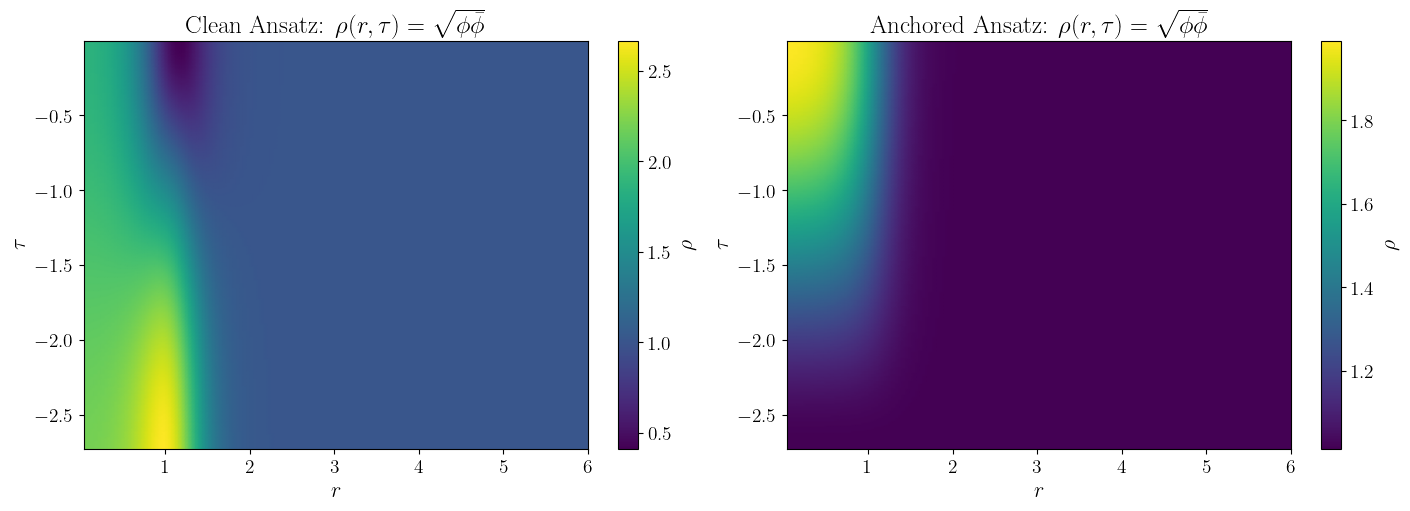

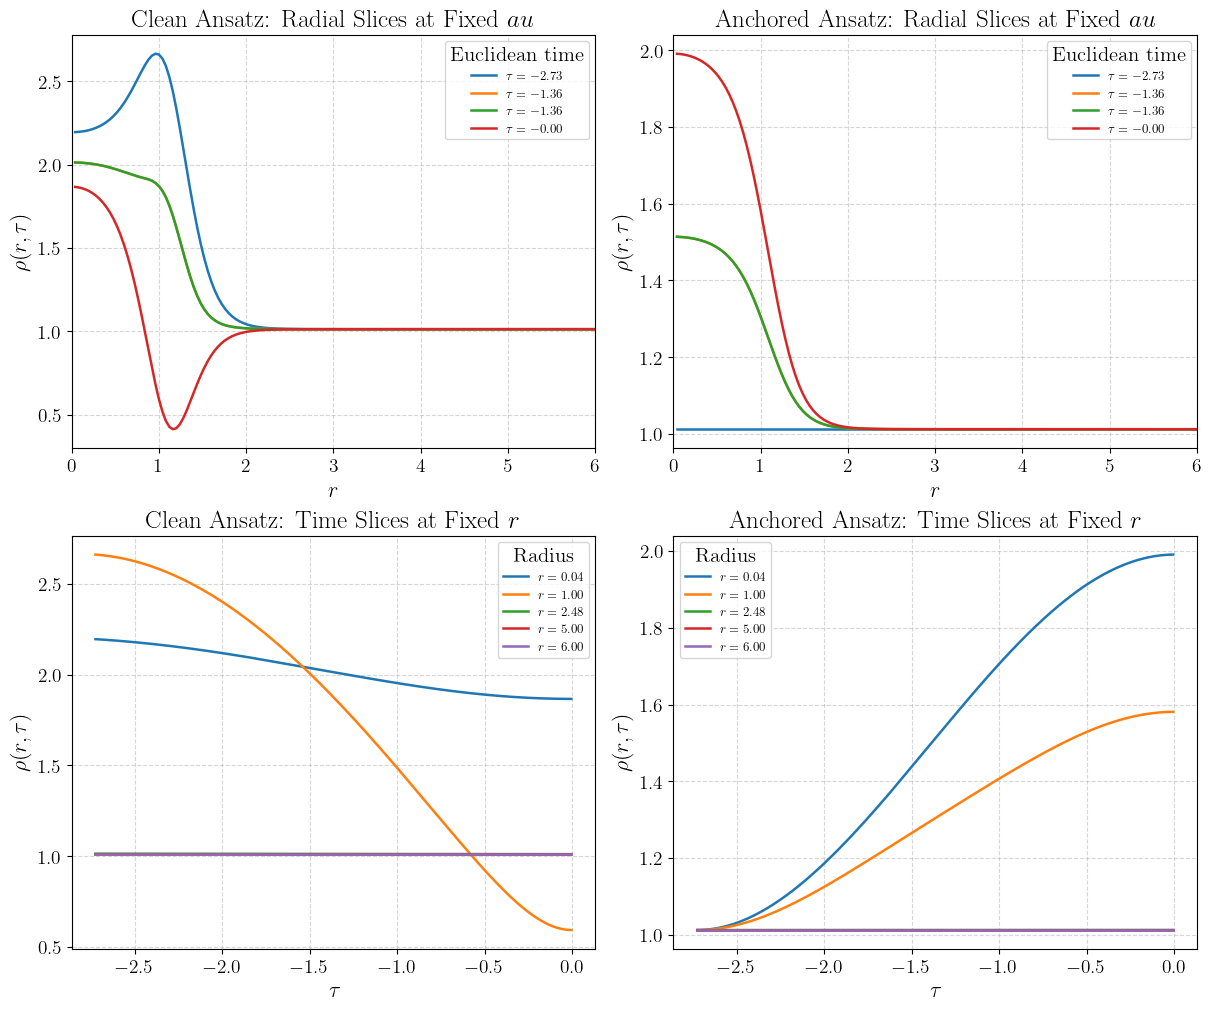


Verifying anchored ansatz boundary conditions:
  At τ = -β/2 = -2.726091:
    φ(r=0) = 1.989929-0.000000j (expected ≈ 1.012378)
    φ(r_max) = 1.012386+0.000000j (expected ≈ 1.012378)
  At τ = 0:
    φ(r=0) = 1.012378+0.000000j (expected ≈ 1.991117)
    φ(r_max) = 1.012378+0.000000j (expected ≈ 1.012386)


In [27]:
# Visualize 2D ansatz fields
if ansatz_clean is not None and grid is not None:
    # Create meshgrid for plotting (use 'xy' indexing for pcolormesh compatibility)
    R, T = np.meshgrid(grid.r, grid.tau, indexing='xy')
    
    # Compute density rho = sqrt((phi * phibar).real)
    # Using .real ensures we get a real-valued density even if phi/phibar are complex
    # This avoids sign-flip artefacts in rho that would appear with sqrt(phi*phibar) directly
    rho_clean = np.sqrt(np.maximum((phi_clean * phibar_clean).real, 0.0))
    rho_anchored = np.sqrt(np.maximum((phi_anchored * phibar_anchored).real, 0.0))
    
    # Plot clean ansatz
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
    
    # Left: clean ansatz density
    # rho_clean has shape (Nr, Ntau), need to transpose for pcolormesh with 'xy' indexing
    # Use 'gouraud' shading which is more robust than 'auto'
    cf0 = axes[0].pcolormesh(R, T, rho_clean.T, shading="gouraud", cmap="viridis")
    axes[0].set_title(r"Clean Ansatz: $\rho(r,\tau) = \sqrt{\phi\bar\phi}$")
    axes[0].set_xlabel(r"$r$")
    axes[0].set_ylabel(r"$\tau$")
    fig.colorbar(cf0, ax=axes[0], label=r"$\rho$")
    
    # Right: anchored ansatz density
    cf1 = axes[1].pcolormesh(R, T, rho_anchored.T, shading="gouraud", cmap="viridis")
    axes[1].set_title(r"Anchored Ansatz: $\rho(r,\tau) = \sqrt{\phi\bar\phi}$")
    axes[1].set_xlabel(r"$r$")
    axes[1].set_ylabel(r"$\tau$")
    fig.colorbar(cf1, ax=axes[1], label=r"$\rho$")
    
    plt.show()
    
    # Plot slices of the ansatz
    rs = grid.r
    taus = grid.tau
    
    # Select representative tau slices
    tau_targets = [grid.tau.min(), grid.tau.min() / 2.0, -beta_ansatz / 4.0, 0.0]
    tau_indices = [int(np.argmin(np.abs(taus - tau_val))) for tau_val in tau_targets]
    
    # Select representative radial locations
    r_targets = [0.0, 1.0, 2.5, 5.0, 7.5]
    r_indices = [int(np.argmin(np.abs(rs - r_val))) for r_val in r_targets]
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
    
    # Get Lr from grid or use default
    Lr_plot = grid.r[-1] if hasattr(grid, 'r') else (GRID_LR if 'GRID_LR' in globals() else 10.0)
    
    # Top left: radial slices at fixed tau (clean) - plot density
    for tau_idx in tau_indices:
        label = rf"$\tau = {taus[tau_idx]:.2f}$"
        axes[0, 0].plot(rs, rho_clean[:, tau_idx], lw=1.8, label=label)
    axes[0, 0].set_xlabel(r"$r$")
    axes[0, 0].set_ylabel(r"$\rho(r,\tau)$")
    axes[0, 0].set_title("Clean Ansatz: Radial Slices at Fixed $\tau$")
    axes[0, 0].set_xlim(0, min(Lr_plot, 9))
    axes[0, 0].grid(True, ls="--", alpha=0.5)
    axes[0, 0].legend(title="Euclidean time", loc="best", fontsize=9)
    
    # Top right: radial slices at fixed tau (anchored) - plot density
    for tau_idx in tau_indices:
        label = rf"$\tau = {taus[tau_idx]:.2f}$"
        axes[0, 1].plot(rs, rho_anchored[:, tau_idx], lw=1.8, label=label)
    axes[0, 1].set_xlabel(r"$r$")
    axes[0, 1].set_ylabel(r"$\rho(r,\tau)$")
    axes[0, 1].set_title("Anchored Ansatz: Radial Slices at Fixed $\tau$")
    axes[0, 1].set_xlim(0, min(Lr_plot, 9))
    axes[0, 1].grid(True, ls="--", alpha=0.5)
    axes[0, 1].legend(title="Euclidean time", loc="best", fontsize=9)
    
    # Bottom left: tau slices at fixed r (clean) - plot density
    for r_idx in r_indices:
        label = rf"$r = {rs[r_idx]:.2f}$"
        axes[1, 0].plot(taus, rho_clean[r_idx, :], lw=1.8, label=label)
    axes[1, 0].set_xlabel(rf"$\tau$")
    axes[1, 0].set_ylabel(rf"$\rho(r,\tau)$")
    axes[1, 0].set_title("Clean Ansatz: Time Slices at Fixed $r$")
    axes[1, 0].grid(True, ls="--", alpha=0.5)
    axes[1, 0].legend(title="Radius", loc="best", fontsize=9)
    
    # Bottom right: tau slices at fixed r (anchored) - plot density
    for r_idx in r_indices:
        label = rf"$r = {rs[r_idx]:.2f}$"
        axes[1, 1].plot(taus, rho_anchored[r_idx, :], lw=1.8, label=label)
    axes[1, 1].set_xlabel(rf"$\tau$")
    axes[1, 1].set_ylabel(rf"$\rho(r,\tau)$")
    axes[1, 1].set_title("Anchored Ansatz: Time Slices at Fixed $r$")
    axes[1, 1].grid(True, ls="--", alpha=0.5)
    axes[1, 1].legend(title="Radius", loc="best", fontsize=9)
    
    plt.show()
    
    # Verify boundary conditions for anchored ansatz
    print("\nVerifying anchored ansatz boundary conditions:")
    print(f"  At τ = -β/2 = {grid.tau.min():.6f}:")
    print(f"    φ(r=0) = {phi_anchored[0, 0]:.6f} (expected ≈ {PHI_HOM:.6f})")
    print(f"    φ(r_max) = {phi_anchored[-1, 0]:.6f} (expected ≈ {PHI_HOM:.6f})")
    print(f"  At τ = 0:")
    print(f"    φ(r=0) = {phi_anchored[0, -1]:.6f} (expected ≈ {phi_bounce[0]:.6f})")
    print(f"    φ(r_max) = {phi_anchored[-1, -1]:.6f} (expected ≈ {phi_bounce[-1]:.6f})")
    
else:
    print("Error: Ansatz not constructed. Please run the previous cell first.")